In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from opfython.models import SupervisedOPF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from imblearn.under_sampling import NearMiss

from scipy.stats import wilcoxon

import logging
import warnings

In [2]:
df = pd.read_csv('NPHA-doctor-visits.csv')

In [3]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [4]:
df.shape

(714, 15)

In [5]:
df.isna().sum()

Number of Doctors Visited                     0
Age                                           0
Phyiscal Health                               0
Mental Health                                 0
Dental Health                                 0
Employment                                    0
Stress Keeps Patient from Sleeping            0
Medication Keeps Patient from Sleeping        0
Pain Keeps Patient from Sleeping              0
Bathroom Needs Keeps Patient from Sleeping    0
Uknown Keeps Patient from Sleeping            0
Trouble Sleeping                              0
Prescription Sleep Medication                 0
Race                                          0
Gender                                        0
dtype: int64

In [6]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [7]:
#histograma das features

# features = df.select_dtypes(include=['number']).columns

# for feature in features:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=df, x=feature, hue='Number of Doctors Visited', kde=False, bins=50, palette="pastel")

#     plt.xlabel(feature)
#     plt.ylabel("Contagem")
#     plt.title(f"Distribuição da feature: {feature}")
#     plt.legend(title="Class")
#     plt.show()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Number of Doctors Visited                   714 non-null    int64
 1   Age                                         714 non-null    int64
 2   Phyiscal Health                             714 non-null    int64
 3   Mental Health                               714 non-null    int64
 4   Dental Health                               714 non-null    int64
 5   Employment                                  714 non-null    int64
 6   Stress Keeps Patient from Sleeping          714 non-null    int64
 7   Medication Keeps Patient from Sleeping      714 non-null    int64
 8   Pain Keeps Patient from Sleeping            714 non-null    int64
 9   Bathroom Needs Keeps Patient from Sleeping  714 non-null    int64
 10  Uknown Keeps Patient from Sleeping          714 n

In [9]:
df.describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714.000000,714.0,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.00000
mean,2.112045,2.0,2.794118,1.988796,3.009804,2.806723,0.247899,0.056022,0.218487,0.504202,0.417367,2.407563,2.829132,1.425770,1.55042
std,0.683441,0.0,0.900939,0.939928,1.361117,0.586582,0.432096,0.230126,0.413510,0.500333,0.493470,0.670349,0.546767,1.003896,0.49780
min,1.000000,2.0,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,1.00000
25%,2.000000,2.0,2.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.00000
50%,2.000000,2.0,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,1.000000,2.00000
75%,3.000000,2.0,3.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.00000
max,3.000000,2.0,5.000000,5.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,5.000000,2.00000


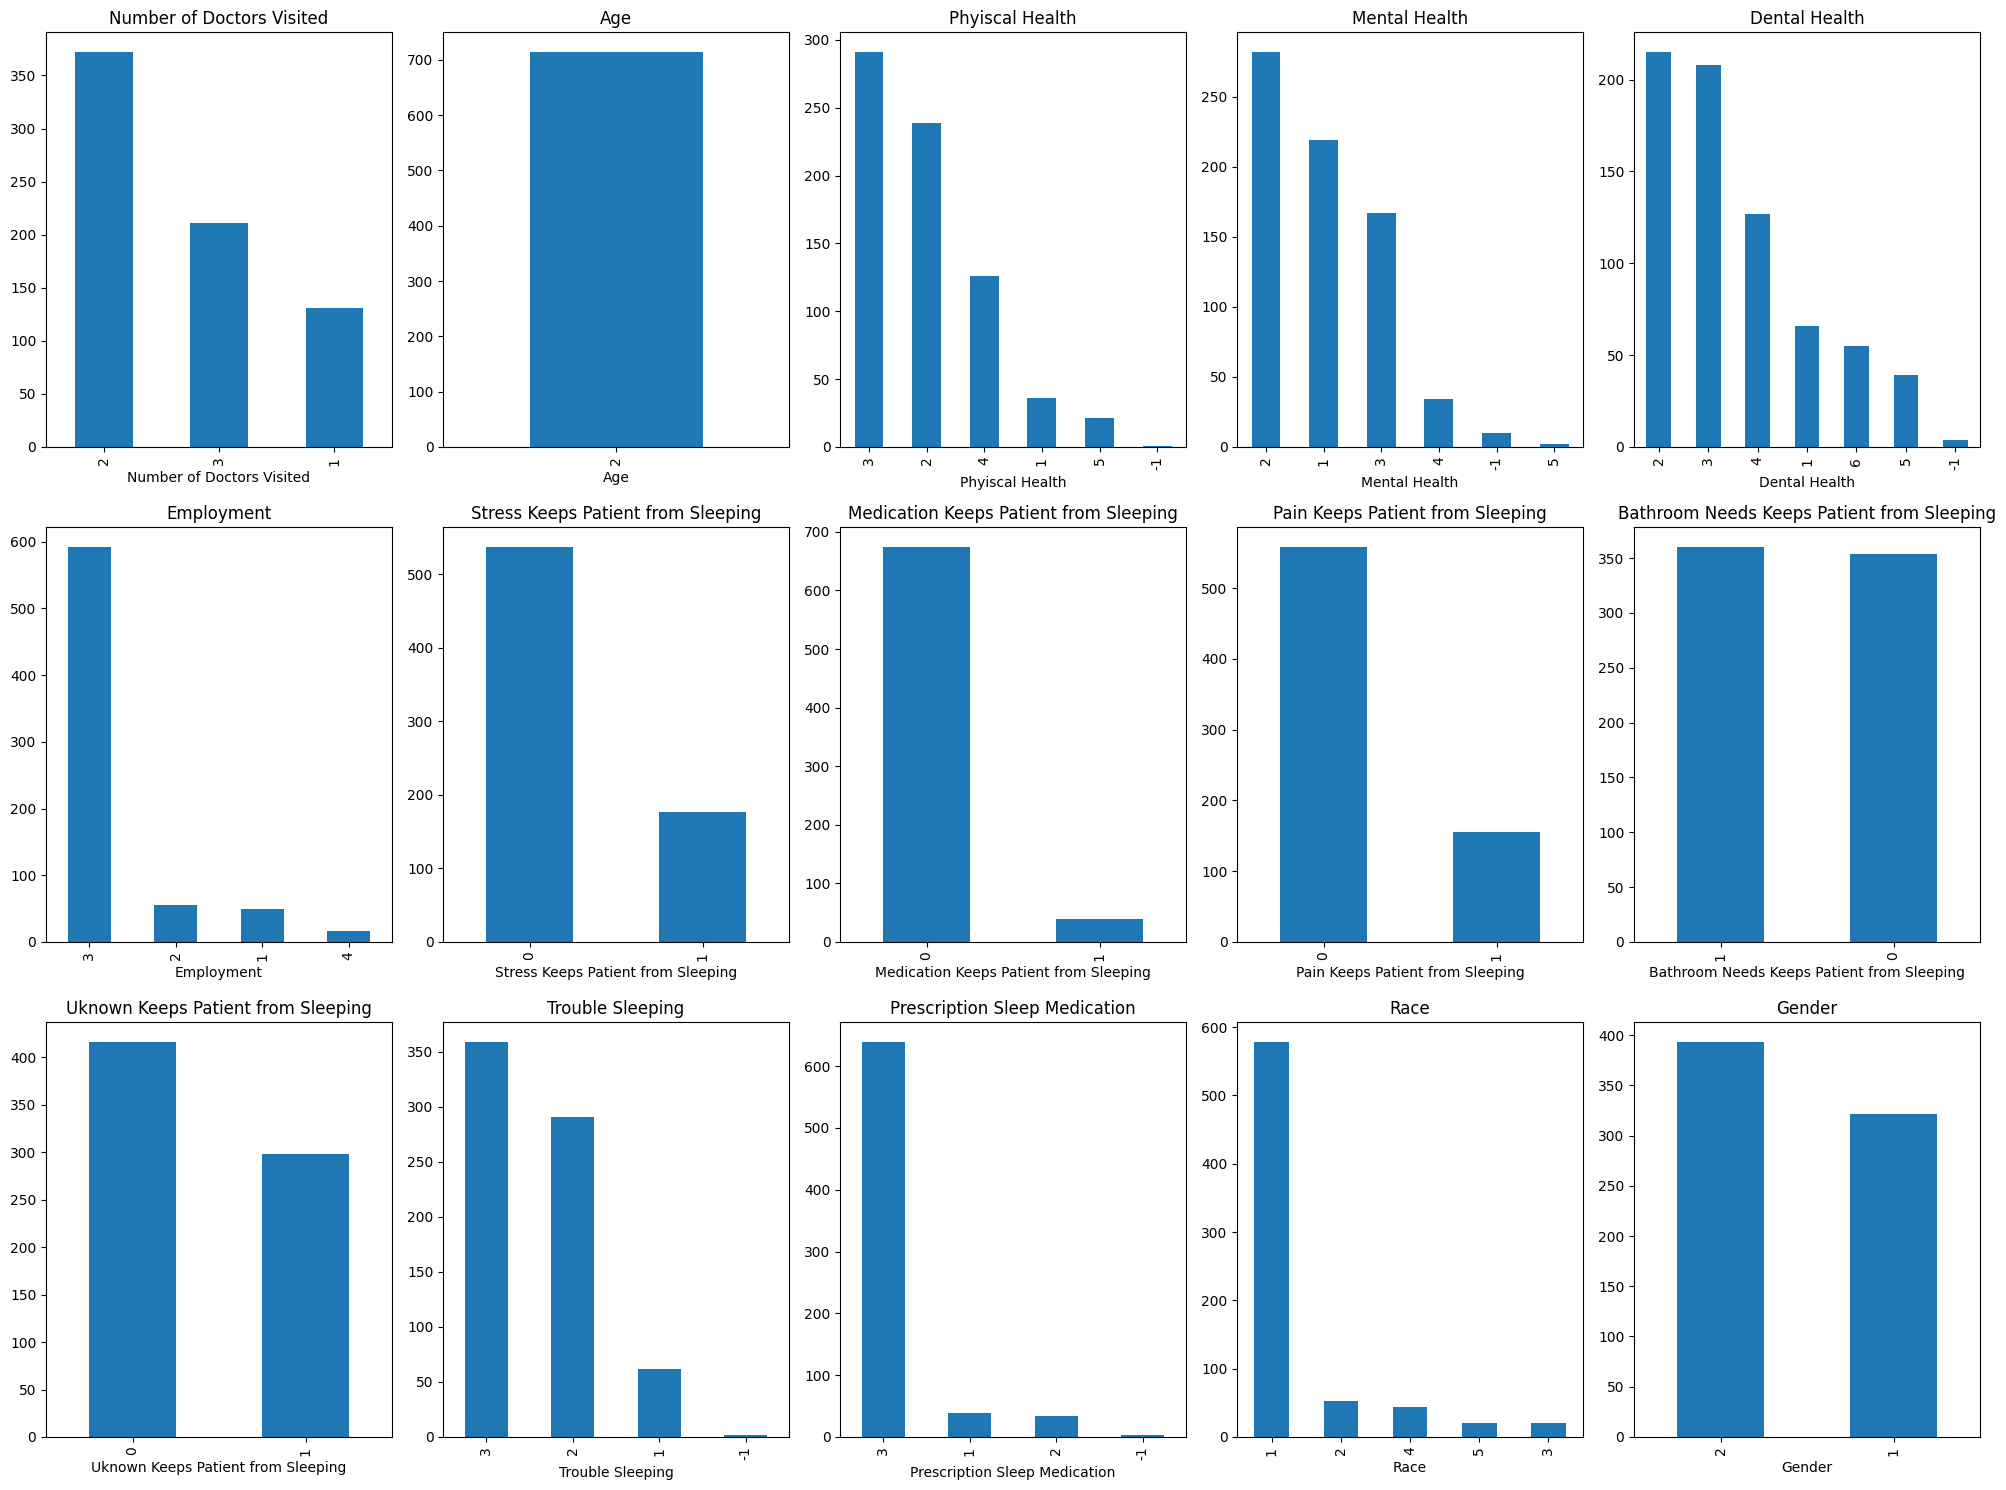

In [10]:
# visualizing the distribution of the features
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.ravel()

for i, column in enumerate(df.columns):
    df[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

In [11]:
df['Number of Doctors Visited'].describe()

count    714.000000
mean       2.112045
std        0.683441
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: Number of Doctors Visited, dtype: float64

In [12]:
df['Age'].describe()

count    714.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: Age, dtype: float64

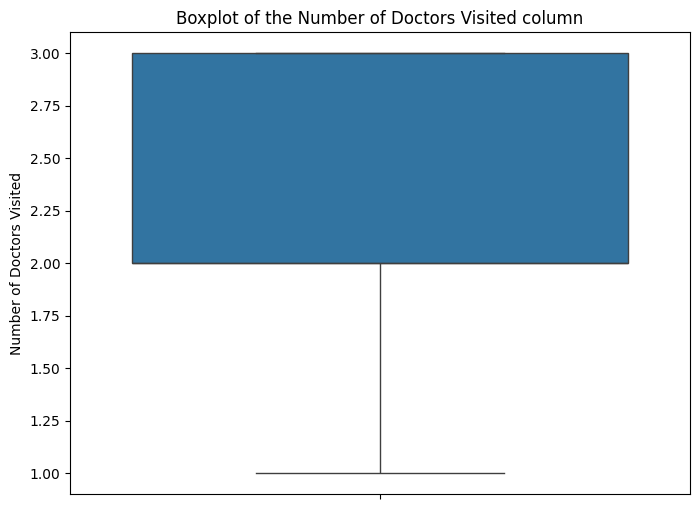

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Number of Doctors Visited', data=df)
plt.title("Boxplot of the Number of Doctors Visited column")
plt.show()

In [14]:
Q1_UP = df['Number of Doctors Visited'].quantile(0.25)
Q2_UP = df['Number of Doctors Visited'].quantile(0.5)
Q3_UP = df['Number of Doctors Visited'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: Number of Doctors Visited")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: Number of Doctors Visited
- Q1: 2.00
- Q2 (Mediana): 2.00
- Q3: 3.00
- Limite Inferior: 0.50
- Limite Superior: 4.50


Existe um viés na Classe 2. Portanto seria bom utilizar tecnica de  subamostragem para a classe super-representada.

In [15]:
# Calculate the class distribution
class_distribution = df['Number of Doctors Visited'].value_counts()
print(class_distribution)

Number of Doctors Visited
2    372
3    211
1    131
Name: count, dtype: int64


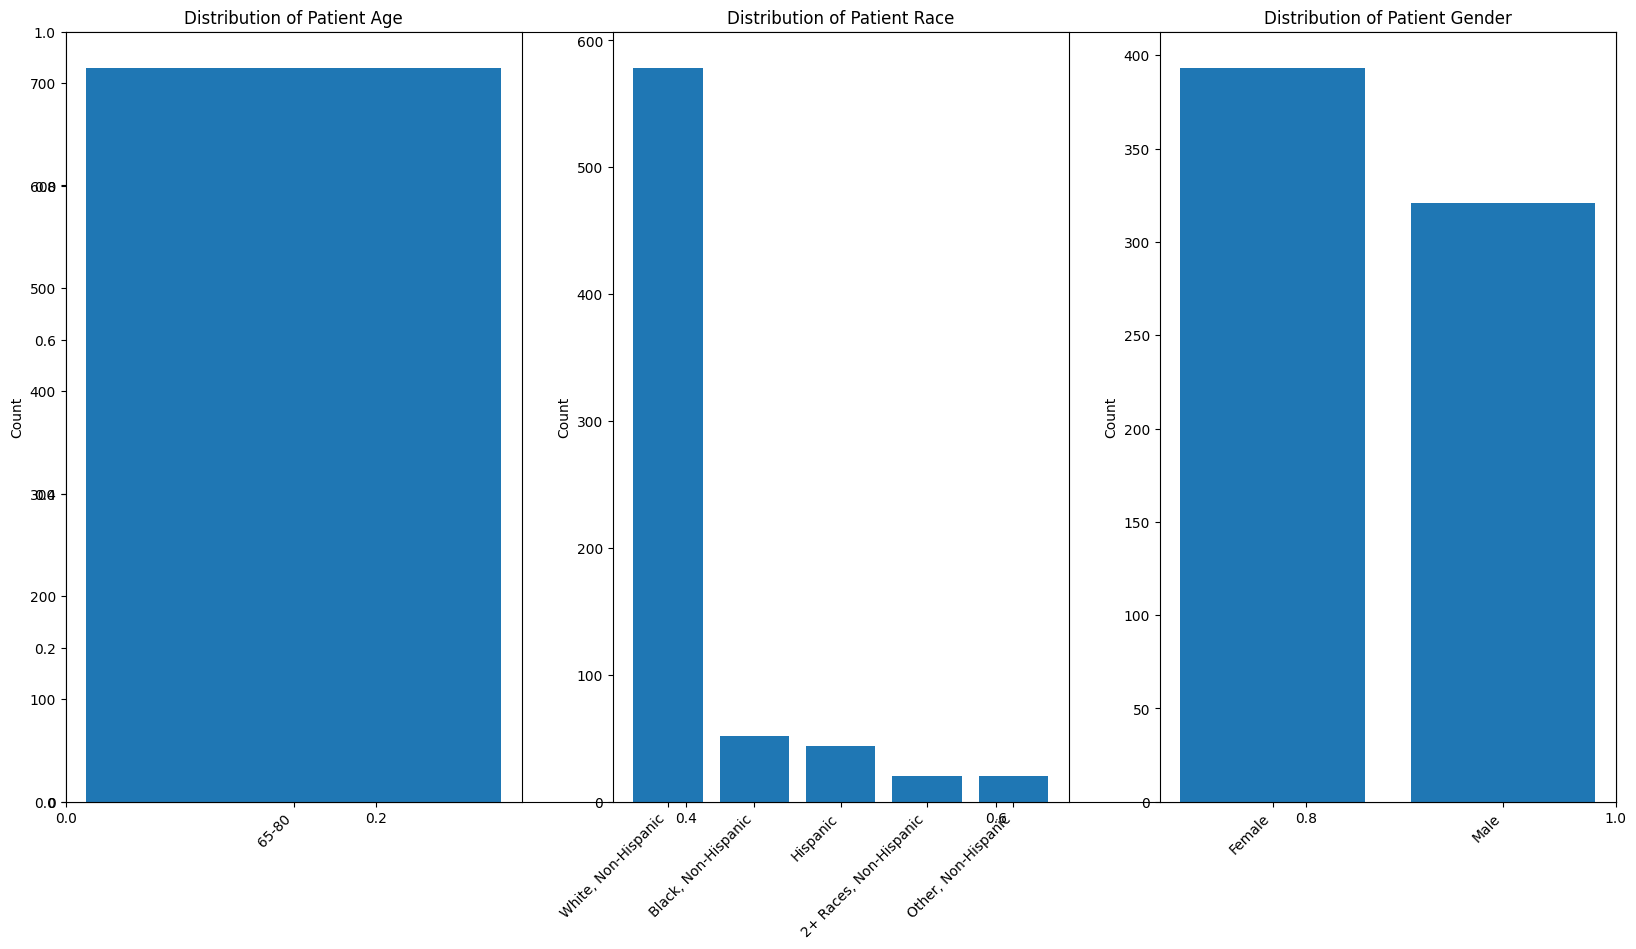

In [16]:
df_ = df.copy()

age_dict = { 1: "50-64", 2: "65-80" }
df_['Age'] = df_['Age'].map(age_dict)

race_dict = { 1: "White, Non-Hispanic", 2: "Black, Non-Hispanic", 3: "Other, Non-Hispanic", 4: "Hispanic", 5: "2+ Races, Non-Hispanic" }
df_['Race'] = df_['Race'].map(race_dict)

gender_dict = { 1: "Male", 2: "Female" }
df_['Gender'] = df_['Gender'].map(gender_dict)

plt.subplots(figsize=(20, 10))
for i, col in enumerate(['Age', 'Race' , 'Gender']):
    plt.subplot(1, 3, i + 1)

    x = df_[col].value_counts()
    plt.bar(x.index, x.values)
    plt.title('Distribution of Patient ' + col)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')

plt.show()

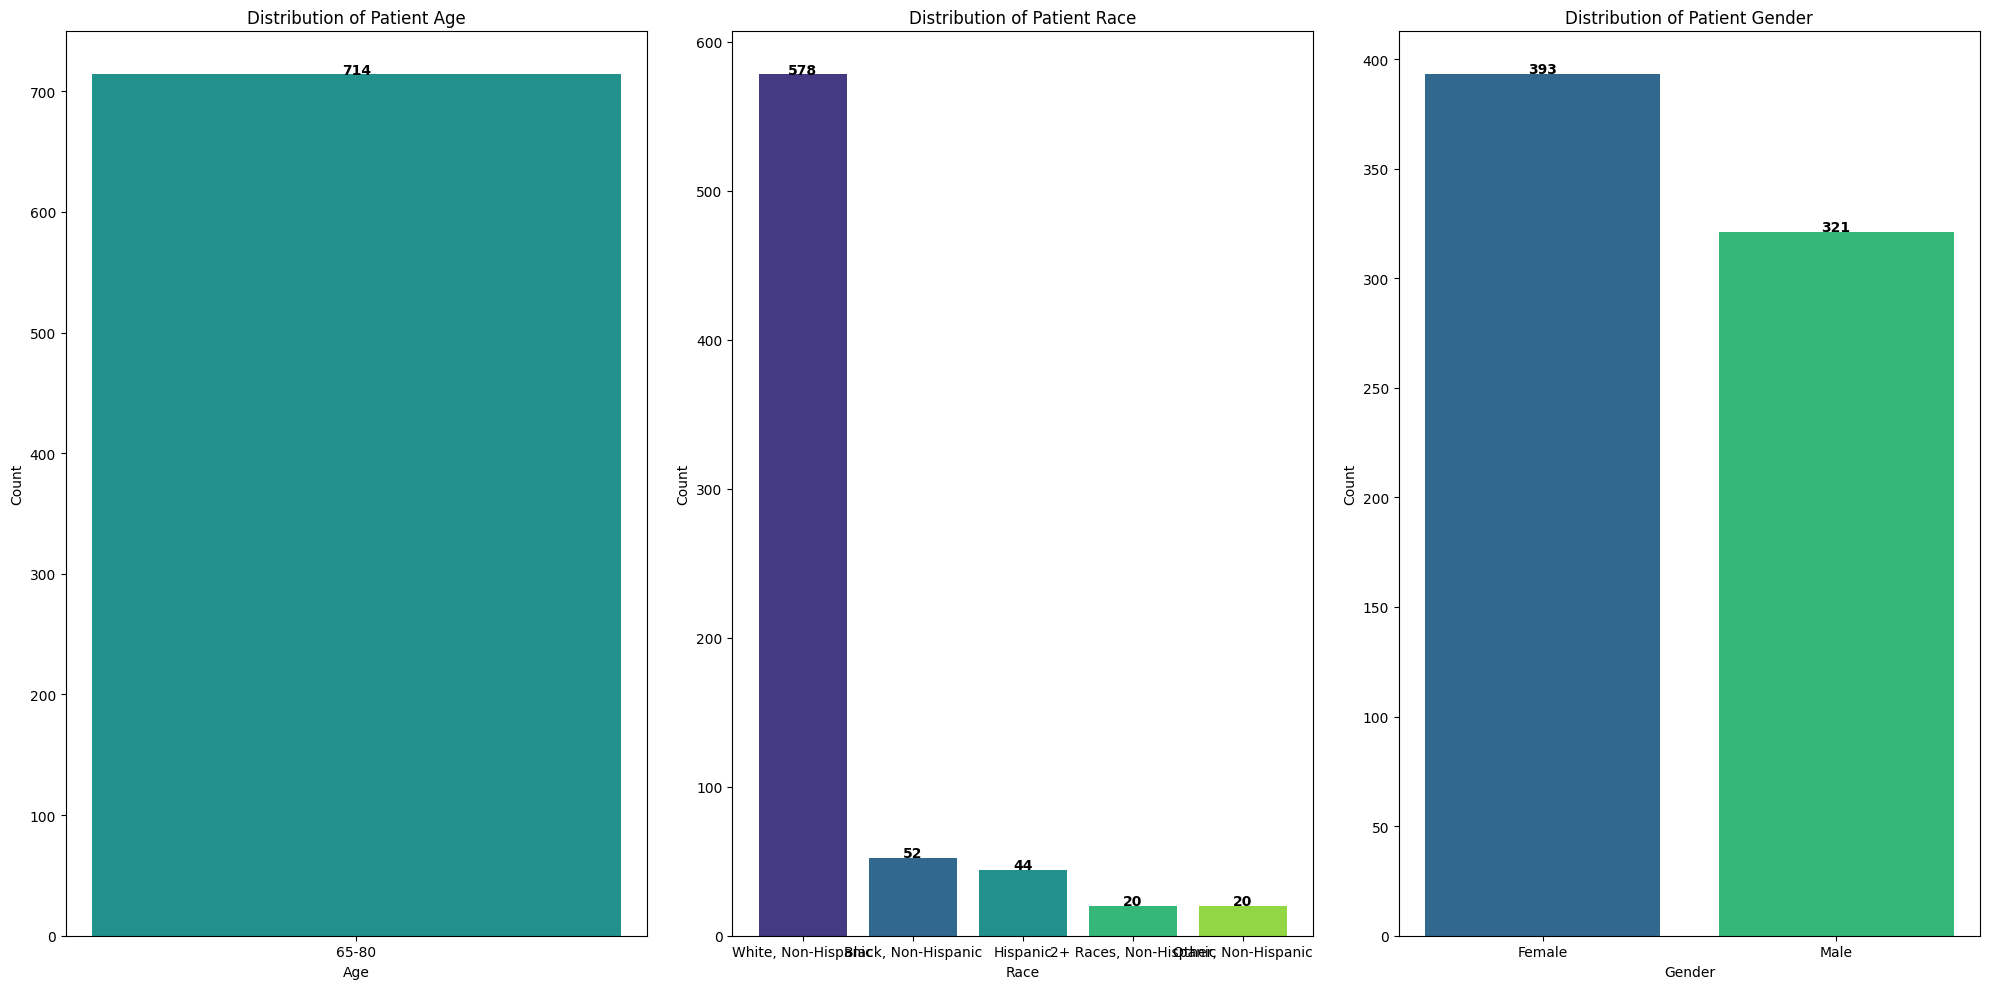

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for i, col in enumerate(['Age', 'Race', 'Gender']):
    x = df_[col].value_counts()
    axes[i].bar(x.index.astype(str), x.values, color=sns.color_palette("viridis", len(x)))
    axes[i].set_title('Distribution of Patient ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Adicionar valores em cima das barras
    for j, v in enumerate(x.values):
        axes[i].text(j, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


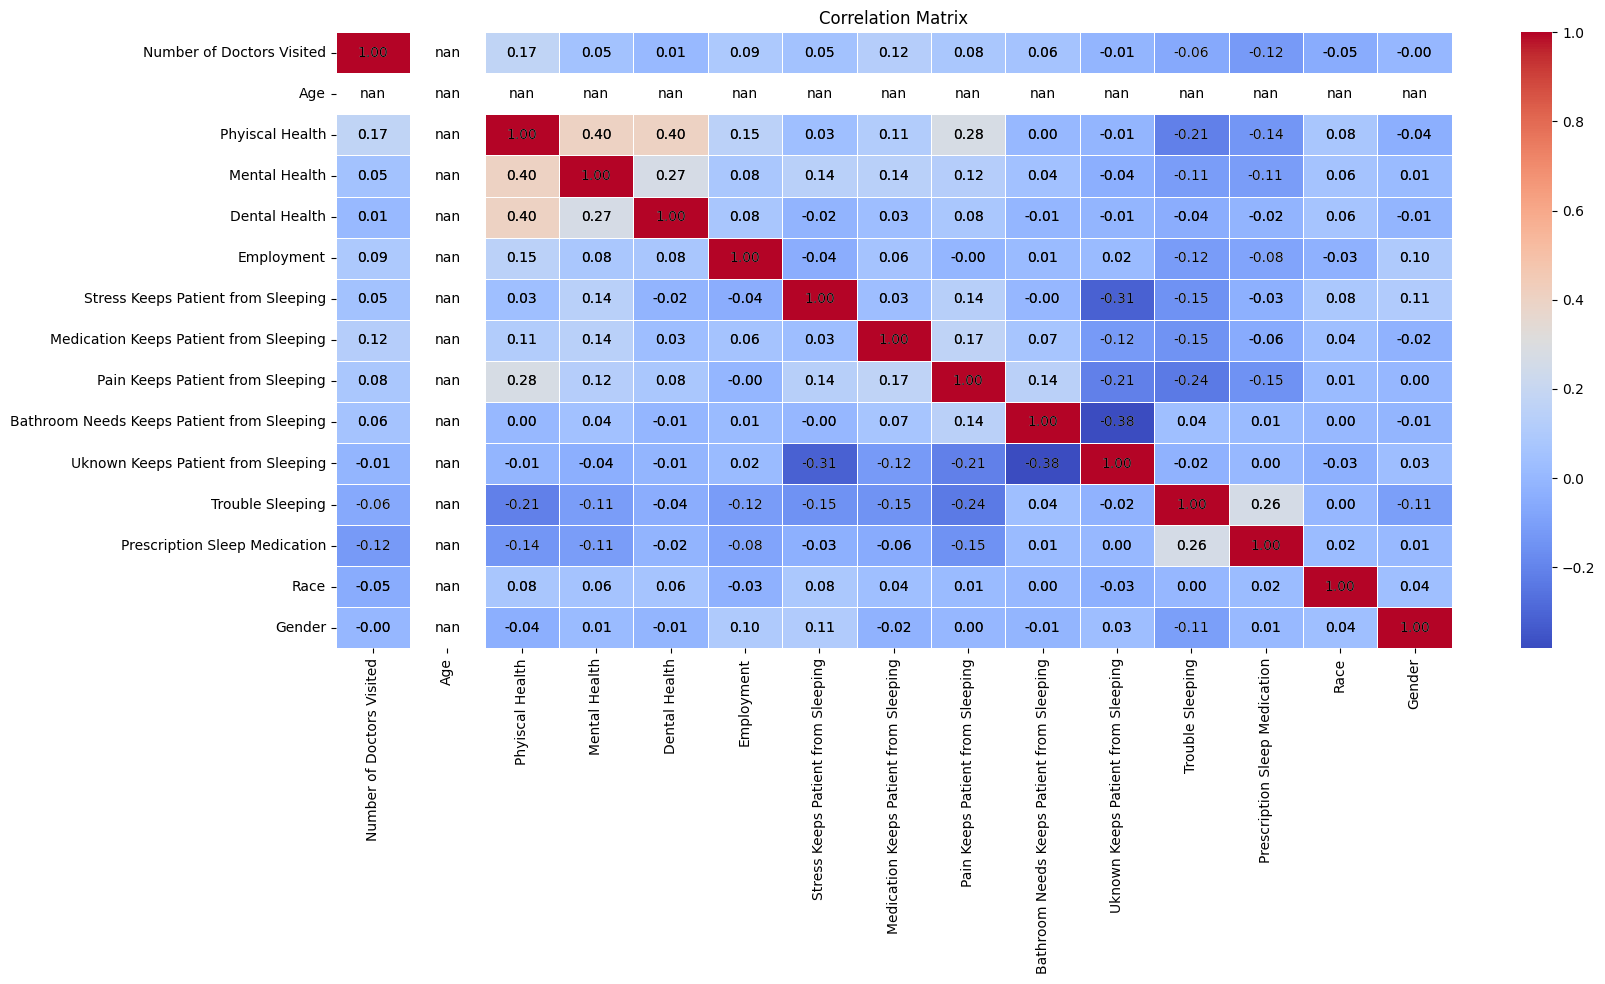

In [18]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

# Add annotations to the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = f"{corr_matrix.iloc[i, j]:.2f}"
        plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.show()

In [19]:
# Substitui todos os valores 3 por 2 na coluna alvo
df['Number of Doctors Visited'] = df['Number of Doctors Visited'].replace(3, 2)

Fazendo One-Hote-Encoding em todas as features por serem categoricas

In [20]:
categorical_features = df.columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)
df_encoded

,Number of Doctors Visited_1,Number of Doctors Visited_2,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,True
1,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False
2,False,True,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,True,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,False,True,True,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,False,True,True,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,True,False
710,False,True,True,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
711,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False
712,False,True,True,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True


In [21]:
df_encoded = df_encoded.reset_index(drop=True)

In [22]:
X = df_encoded.drop(columns=['Number of Doctors Visited_1', 'Number of Doctors Visited_2'])
y = df_encoded[['Number of Doctors Visited_1', 'Number of Doctors Visited_2']]

In [23]:
X

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


In [24]:
y

,Number of Doctors Visited_1,Number of Doctors Visited_2
0,False,True
1,False,True
2,False,True
3,True,False
4,False,True
...,...,...
709,False,True
710,False,True
711,False,True
712,False,True


In [25]:
# feature_importances = pd.DataFrame(model.feature_importances_,
#                                    index = X.columns,
#                                    columns=['importance']).sort_values('importance', ascending=False)

# # Plotting
# plt.figure(figsize=(10, 6))
# feature_importances.plot(kind='barh')

In [26]:
y

,Number of Doctors Visited_1,Number of Doctors Visited_2
0,False,True
1,False,True
2,False,True
3,True,False
4,False,True
...,...,...
709,False,True
710,False,True
711,False,True
712,False,True


In [27]:
colunas_lixo = [
    'Race_5', 'Uknown Keeps Patient from Sleeping_0', 'Prescription Sleep Medication_2',
    'Phyiscal Health_1', 'Mental Health_-1', 'Race_4', 'Dental Health_1',
    'Prescription Sleep Medication_-1', 'Dental Health_-1', 'Mental Health_5',
    'Phyiscal Health_-1', 'Age_2', 'Gender_1', 'Phyiscal Health_3', 'Phyiscal Health_5', 'Dental Health_3',
    'Race_2', 'Trouble Sleeping_3', 'Mental Health_3', 'Gender_2',
    'Employment_1', 'Trouble Sleeping_2', 'Dental Health_6', 'Trouble Sleeping_-1'
]

In [28]:
X = X.drop(columns=colunas_lixo)

In [29]:
print(f"Dimensões atuais: {X.shape}")

Dimensões atuais: (714, 25)


In [30]:
X_resampled = X.values
y_resampled = y.values

In [31]:
y = np.argmax(y_resampled, axis=1)

y = pd.Series(y)
class_distribution = y.value_counts()
print("Class distribution after NearMiss undersampling:")
print(class_distribution)

Class distribution after NearMiss undersampling:
1    583
0    131
Name: count, dtype: int64


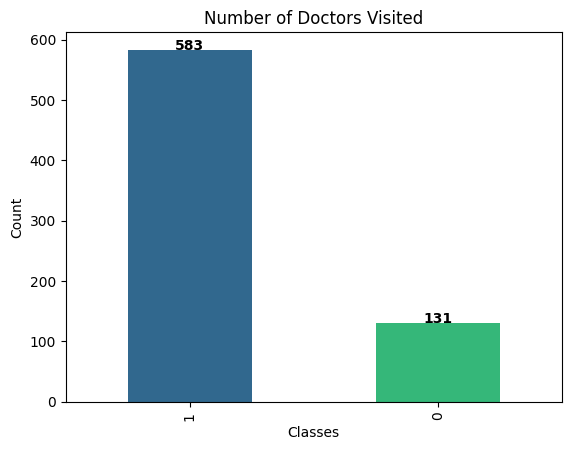

In [32]:
ax = y.value_counts().plot(kind='bar', title='Number of Doctors Visited', color=sns.color_palette("viridis", len(y.value_counts())))
ax.set_xlabel('Classes')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5, str(int(p.get_height())), ha='center', fontweight='bold')
plt.show()


In [33]:
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

In [34]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_escalonado)
# Crio um DataFrame temporário só pra ser mais fácil de pintar
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
# Adiciono uma coluna com a resposta certa (Y) para ele colorir os pontinhos
# Assumindo que a sua resposta é o 'y'
df_pca['Classe_Alvo'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

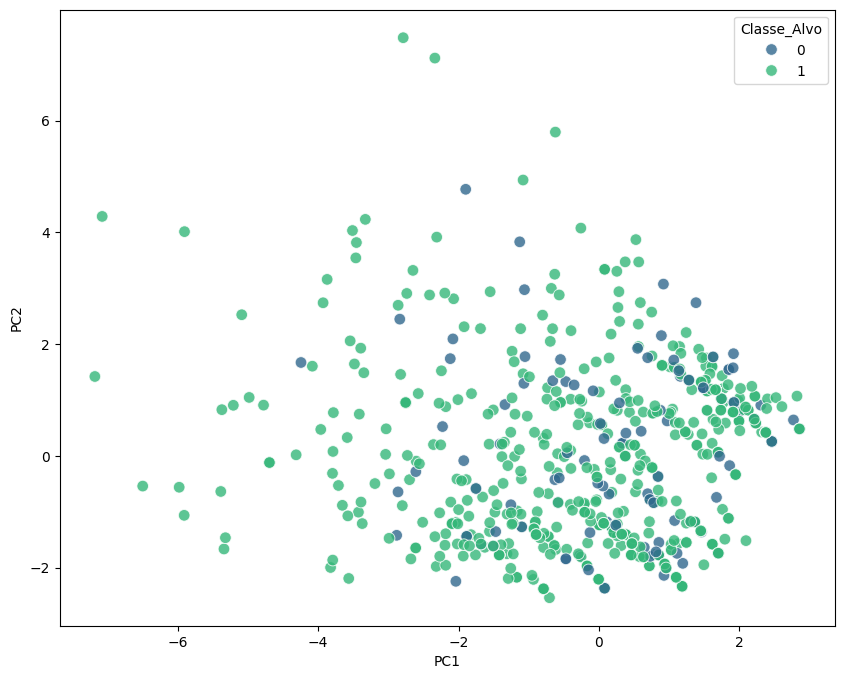

In [35]:
plt.figure(figsize=(10, 8))
# O seaborn desenha o Scatter Plot com Cores automáticas!
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis', # Tente 'Set1' ou 'coolwarm' também
    data=df_pca, 
    alpha=0.8,
    s=70 # Tamanho da bolinha
)

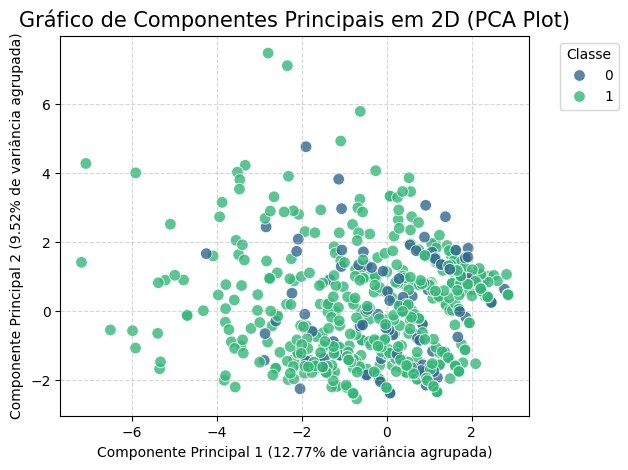

In [36]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

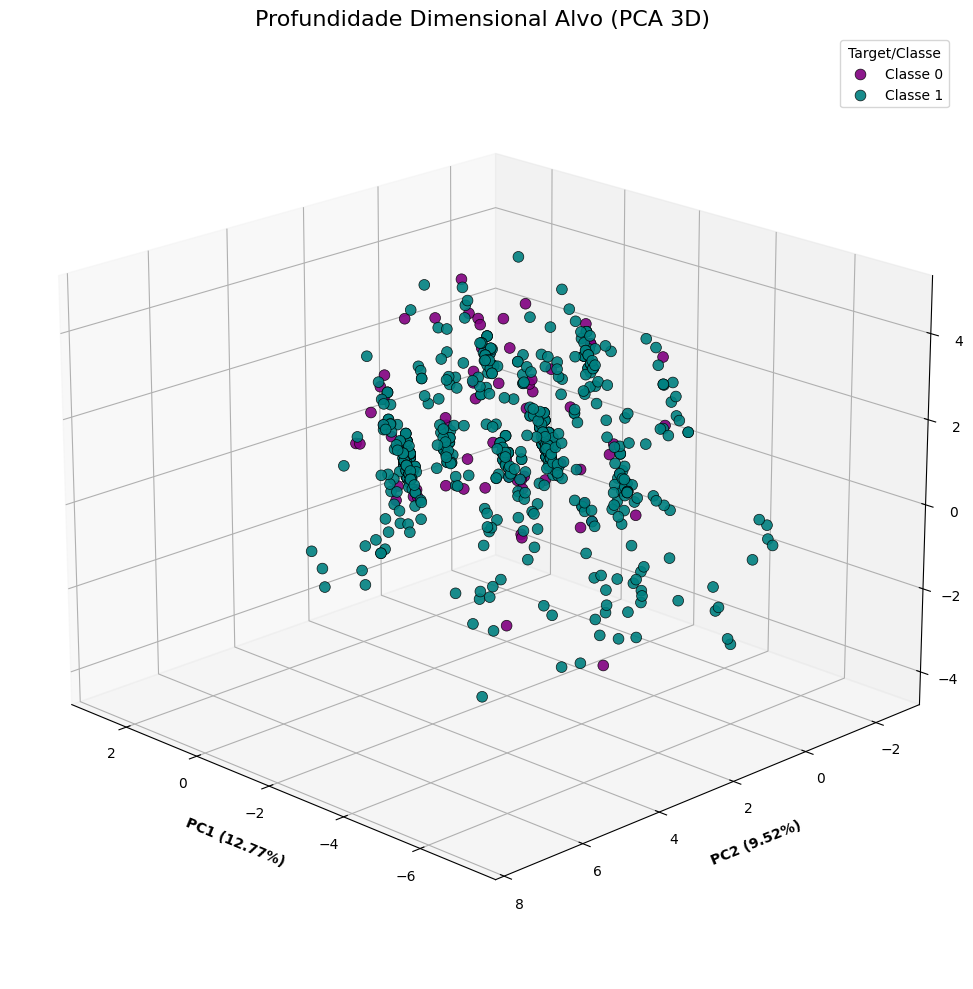

In [37]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_escalonado)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()


In [38]:
df = pd.DataFrame(X, columns=X.columns)

In [39]:
df_encoded.shape

(714, 51)

In [40]:
df

,Phyiscal Health_2,Phyiscal Health_4,Mental Health_1,Mental Health_2,Mental Health_4,Dental Health_2,Dental Health_4,Dental Health_5,Employment_2,Employment_3,...,Pain Keeps Patient from Sleeping_0,Pain Keeps Patient from Sleeping_1,Bathroom Needs Keeps Patient from Sleeping_0,Bathroom Needs Keeps Patient from Sleeping_1,Uknown Keeps Patient from Sleeping_1,Trouble Sleeping_1,Prescription Sleep Medication_1,Prescription Sleep Medication_3,Race_1,Race_3
0,False,True,False,False,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,True,False
1,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
2,False,False,False,True,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,False,False
3,False,False,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,True,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
710,True,False,False,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,True,True,False
711,False,True,False,True,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
712,False,False,True,False,False,False,False,False,False,True,...,False,True,False,True,True,False,False,True,True,False


In [41]:
x = df

In [42]:
x

,Phyiscal Health_2,Phyiscal Health_4,Mental Health_1,Mental Health_2,Mental Health_4,Dental Health_2,Dental Health_4,Dental Health_5,Employment_2,Employment_3,...,Pain Keeps Patient from Sleeping_0,Pain Keeps Patient from Sleeping_1,Bathroom Needs Keeps Patient from Sleeping_0,Bathroom Needs Keeps Patient from Sleeping_1,Uknown Keeps Patient from Sleeping_1,Trouble Sleeping_1,Prescription Sleep Medication_1,Prescription Sleep Medication_3,Race_1,Race_3
0,False,True,False,False,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,True,False
1,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
2,False,False,False,True,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,False,False
3,False,False,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,True,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
710,True,False,False,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,True,True,False
711,False,True,False,True,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
712,False,False,True,False,False,False,False,False,False,True,...,False,True,False,True,True,False,False,True,True,False


In [43]:
x = x.values

In [44]:
x

array([[False,  True, False, ...,  True,  True, False],
       [False,  True, False, ...,  True,  True, False],
       [False, False, False, ...,  True, False, False],
       ...,
       [False,  True, False, ...,  True,  True, False],
       [False, False,  True, ...,  True,  True, False],
       [False, False, False, ...,  True,  True, False]], shape=(714, 25))

In [45]:
param_grid_KNN = {
    'n_neighbors': [10, 20, 30, 40],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
}

In [46]:
param_grid_DT = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
}

In [47]:
param_grid_RF = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [2, 5, 10],
}

In [48]:
param_grid_SVM = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1],
    'probability': [True]
}

In [49]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0], # Parâmetro decisivo para ignorar névoas nos dados
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [50]:
param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],  # Valores de regularização variando de muito rígidos a flexíveis
     'solver': ['saga'],       # Melhor pra lidar com mais punições simultâneas
     'penalty': ['l1', 'l2'],  # Penas de L1 descartam features fracas e as jogam pra zero!
}

In [51]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [52]:
param_grid_NB = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [53]:
param_grid_NC = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.5, 1.0]
}

In [54]:
param_grid_OPF = {
    'distance':['euclidean', 'squared_euclidean', 'log_squared_euclidean', 
                'manhattan', 'canberra', 'chebyshev']
}

In [55]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [56]:
S = MinMaxScaler()

In [57]:
test_scores_KNN = []
acc_test_scores_KNN = []
precision_test_scores_KNN = []
recall_test_scores_KNN = []
f1_test_scores_KNN = []
auroc_test_scores_KNN = []

test_scores_DT = []
acc_test_scores_DT = []
precision_test_scores_DT = []
recall_test_scores_DT = []
f1_test_scores_DT = []
auroc_test_scores_DT = []

test_scores_RF = []
acc_test_scores_RF = []
precision_test_scores_RF = []
recall_test_scores_RF = []
f1_test_scores_RF = []
auroc_test_scores_RF = []

test_scores_SVM = []
acc_test_scores_SVM = []
precision_test_scores_SVM = []
recall_test_scores_SVM = []
f1_test_scores_SVM = []
auroc_test_scores_SVM = []

test_scores_MLP = []
acc_test_scores_MLP = []
precision_test_scores_MLP = []
recall_test_scores_MLP = []
f1_test_scores_MLP = []
auroc_test_scores_MLP = []

test_scores_LR = []
acc_test_scores_LR = []
precision_test_scores_LR = []
recall_test_scores_LR = []
f1_test_scores_LR = []
auroc_test_scores_LR = []

test_scores_XGB = []
acc_test_scores_XGB = []
precision_test_scores_XGB = []
recall_test_scores_XGB = []
f1_test_scores_XGB = []
auroc_test_scores_XGB = []

test_scores_NB = []
acc_test_scores_NB = []
precision_test_scores_NB = []
recall_test_scores_NB = []
f1_test_scores_NB = []
auroc_test_scores_NB = []

test_scores_NC = []
acc_test_scores_NC = []
precision_test_scores_NC = []
recall_test_scores_NC = []
f1_test_scores_NC = []
auroc_test_scores_NC = []

test_scores_OPF = []
acc_test_scores_OPF = []
precision_test_scores_OPF = []
recall_test_scores_OPF = []
f1_test_scores_OPF = []
auroc_test_scores_OPF = []

In [58]:
confusion_matrices_KNN = []
confusion_matrices_DT = []
confusion_matrices_RF = []
confusion_matrices_SVM = []
confusion_matrices_MLP = []
confusion_matrices_LR = []
confusion_matrices_XGB = []
confusion_matrices_NB = []
confusion_matrices_NC = []
confusion_matrices_OPF = []

In [59]:
# Estrutura para guardar os resultados do MDI
resultados_mdi = {
    'DT': [], 'RF': [], 'XGB': [], 'OPF': []
}

In [60]:
gridsearch_results_f1 = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [61]:
gridsearch_results_acc = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [62]:
# função de seleção f1_macro na validação interna
def validation_metric(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

In [ ]:
logging.getLogger("opfython").disabled = True
logging.disable(logging.CRITICAL)
warnings.filterwarnings("ignore")

In [64]:
for i, (train_index, test_index) in enumerate(kfold.split(x)):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    x_train_D, x_val, y_train_D, y_val = train_test_split(x_train, y_train, test_size=0.2)

    params_KNN = []
    f1_val_KNN = []
    acc_val_KNN = []

    params_DT = []
    f1_val_DT = []
    acc_val_DT = []

    params_RF = []
    f1_val_RF = []
    acc_val_RF = []

    params_SVM = []
    f1_val_SVM = []
    acc_val_SVM = []

    params_MLP = []
    f1_val_MLP = []
    acc_val_MLP = []

    params_LR = []
    f1_val_LR = []
    acc_val_LR = []

    params_XGB = []
    f1_val_XGB = []
    acc_val_XGB = []

    params_NB = []
    f1_val_NB = []
    acc_val_NB = []

    params_NC = []
    f1_val_NC = []
    acc_val_NC = []

    params_OPF = []
    f1_val_OPF = []
    acc_val_OPF = []

    x_train_S = S.fit_transform(x_train)
    x_test_S = S.transform(x_test)


    x_train_D_S = S.fit_transform(x_train_D)
    x_val_S = S.transform(x_val)


    for params in ParameterGrid(param_grid_KNN):
        knn = KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metric'])
        knn.fit(x_train_D_S, y_train_D)
        y_pred = knn.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_KNN.append(params)
        f1_val_KNN.append(validation_metric(y_val, y_pred))
        acc_val_KNN.append(acc)

    for params in ParameterGrid(param_grid_DT):
        dt = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=42)
        dt.fit(x_train_D_S, y_train_D)
        y_pred = dt.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_DT.append(params)
        f1_val_DT.append(validation_metric(y_val, y_pred))
        acc_val_DT.append(acc)

    for params in ParameterGrid(param_grid_RF):
        rf = RandomForestClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
        rf.fit(x_train_D_S, y_train_D)
        y_pred = rf.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_RF.append(params)
        f1_val_RF.append(validation_metric(y_val, y_pred))
        acc_val_RF.append(acc)

    for params in ParameterGrid(param_grid_SVM):
        svm = SupportVectorMachineClassifier(C=params['C'], kernel=params['kernel'], probability=True, random_state=42)
        svm.fit(x_train_D_S, y_train_D)
        y_pred = svm.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_SVM.append(params)
        f1_val_SVM.append(validation_metric(y_val, y_pred))
        acc_val_SVM.append(acc)

    for params in ParameterGrid(param_grid_MLP):

      mlp = MLPClassifier(
          hidden_layer_sizes=params['hidden_layer_sizes'],
          alpha=params['alpha'],
          learning_rate_init=params['learning_rate_init'],
          activation=params['activation'],
          solver=params['solver'],
          max_iter=params['max_iter'],
          early_stopping=params['early_stopping'],
          random_state=params['random_state']
      )

      mlp.fit(x_train_D_S, y_train_D)
      y_pred = mlp.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_MLP.append(params)
      f1_val_MLP.append(validation_metric(y_val, y_pred))
      acc_val_MLP.append(acc)

    for params in ParameterGrid(param_grid_LR):
      lr = LogisticRegression(C=params['C'], solver='saga', max_iter=1000, random_state=42)
      lr.fit(x_train_D_S, y_train_D)
      y_pred = lr.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_LR.append(params)
      f1_val_LR.append(validation_metric(y_val, y_pred))
      acc_val_LR.append(acc)

    for params in ParameterGrid(param_grid_XGB):
      xgb = XGBClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
      xgb.fit(x_train_D_S, y_train_D)
      y_pred = xgb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_XGB.append(params)
      f1_val_XGB.append(validation_metric(y_val, y_pred))
      acc_val_XGB.append(acc)

    for params in ParameterGrid(param_grid_NB):
      nb = GaussianNB(var_smoothing=params['var_smoothing'])
      nb.fit(x_train_D_S, y_train_D)
      y_pred = nb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NB.append(params)
      f1_val_NB.append(validation_metric(y_val, y_pred))
      acc_val_NB.append(acc)

    for params in ParameterGrid(param_grid_NC):
      nc = NearestCentroid(metric=params['metric'], shrink_threshold=params['shrink_threshold'])
      nc.fit(x_train_D_S, y_train_D)
      y_pred = nc.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NC.append(params)
      f1_val_NC.append(validation_metric(y_val, y_pred))
      acc_val_NC.append(acc)

    for params in ParameterGrid(param_grid_OPF):
      opf = SupervisedOPF(distance=params['distance'])
      opf.fit(np.array(x_train_D_S), np.array(y_train_D, dtype=np.int32))
      y_pred = opf.predict(np.array(x_val_S))
      acc = accuracy_score(y_val, y_pred)
      params_OPF.append(params)
      f1_val_OPF.append(validation_metric(y_val, y_pred))
      acc_val_OPF.append(acc)

    print(f"Fold {i+1}:")

    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    best_params_DT  = params_DT[f1_val_DT.index(max(f1_val_DT))]
    best_params_RF  = params_RF[f1_val_RF.index(max(f1_val_RF))]
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    best_params_LR  = params_LR[f1_val_LR.index(max(f1_val_LR))]
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    best_params_NB = params_NB[f1_val_NB.index(max(f1_val_NB))]
    best_params_NC = params_NC[f1_val_NC.index(max(f1_val_NC))]
    best_params_OPF = params_OPF[f1_val_OPF.index(max(f1_val_OPF))]


    gridsearch_results_f1['KNN'].append(max(f1_val_KNN))
    gridsearch_results_acc['KNN'].append(max(acc_val_KNN))

    gridsearch_results_f1['DT'].append(max(f1_val_DT))
    gridsearch_results_acc['DT'].append(max(acc_val_DT))  

    gridsearch_results_f1['RF'].append(max(f1_val_RF))
    gridsearch_results_acc['RF'].append(max(acc_val_RF))  

    gridsearch_results_f1['SVM'].append(max(f1_val_SVM))
    gridsearch_results_acc['SVM'].append(max(acc_val_SVM))

    gridsearch_results_f1['MLP'].append(max(f1_val_MLP))
    gridsearch_results_acc['MLP'].append(max(acc_val_MLP))

    gridsearch_results_f1['LR'].append(max(f1_val_LR))
    gridsearch_results_acc['LR'].append(max(acc_val_LR))  

    gridsearch_results_f1['XGB'].append(max(f1_val_XGB))
    gridsearch_results_acc['XGB'].append(max(acc_val_XGB))

    gridsearch_results_f1['NB'].append(max(f1_val_NB))
    gridsearch_results_acc['NB'].append(max(acc_val_NB))  

    gridsearch_results_f1['NC'].append(max(f1_val_NC))
    gridsearch_results_acc['NC'].append(max(acc_val_NC))

    gridsearch_results_f1['OPF'].append(max(f1_val_OPF))
    gridsearch_results_acc['OPF'].append(max(acc_val_OPF)) 


    knn = KNeighborsClassifier(n_neighbors=best_params_KNN['n_neighbors'], metric=best_params_KNN['metric'])
    knn.fit(x_train_S, y_train)
    y_pred_knn = knn.predict(x_test_S)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
    knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
    knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
    knn_auroc = roc_auc_score(y_test, y_pred_knn, average='weighted')

    cm_knn = confusion_matrix(y_test, y_pred_knn)
    confusion_matrices_KNN.append(cm_knn)

    acc_test_scores_KNN.append(knn_acc)
    precision_test_scores_KNN.append(knn_precision)
    recall_test_scores_KNN.append(knn_recall)
    f1_test_scores_KNN.append(knn_f1)
    auroc_test_scores_KNN.append(knn_auroc)

    print(f"\tKNeighborsClassifier:")
    print(f"\t- Melhor n_neighbors: {best_params_KNN['n_neighbors']}")
    print(f"\t- acuracia do teste: {knn_acc:.2f}")
    print(f"\t- Precision no teste: {knn_precision:.4f}")
    print(f"\t- Recall no teste: {knn_recall:.4f}")
    print(f"\t- F1 no teste: {knn_f1:.4f}")
    print(f"\t- AUROC no teste: {knn_auroc:.4f}")

    dt = DecisionTreeClassifier(max_depth=best_params_DT['max_depth'], random_state=42)
    dt.fit(x_train_S, y_train)
    y_pred_dt = dt.predict(x_test_S)
    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
    dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
    dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
    dt_auroc = roc_auc_score(y_test, y_pred_dt, average='weighted')


    resultados_mdi['DT'].append(dt.feature_importances_)

    cm_dt = confusion_matrix(y_test, y_pred_dt)
    confusion_matrices_DT.append(cm_dt)

    acc_test_scores_DT.append(dt_acc)
    precision_test_scores_DT.append(dt_precision)
    recall_test_scores_DT.append(dt_recall)
    f1_test_scores_DT.append(dt_f1)
    auroc_test_scores_DT.append(dt_auroc)


    print(f"\n\tDecisionTreeClassifier:")
    print(f"\t- Melhor max_depth: {best_params_DT['max_depth']}")
    print(f"\t- acuracia do teste: {dt_acc:.2f}")
    print(f"\t- Precision no teste: {dt_precision:.4f}")
    print(f"\t- Recall no teste: {dt_recall:.4f}")
    print(f"\t- F1 no teste: {dt_f1:.4f}")
    print(f"\t- AUROC no teste: {dt_auroc:.4f}")

    rf = RandomForestClassifier(n_estimators=best_params_RF['n_estimators'], max_depth=best_params_RF['max_depth'], random_state=42)
    rf.fit(x_train_S, y_train)
    y_pred_rf = rf.predict(x_test_S)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
    rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
    rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
    rf_auroc = roc_auc_score(y_test, y_pred_rf, average='weighted')

    resultados_mdi['RF'].append(rf.feature_importances_)

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    confusion_matrices_RF.append(cm_rf)

    acc_test_scores_RF.append(rf_acc)
    precision_test_scores_RF.append(rf_precision)
    recall_test_scores_RF.append(rf_recall)
    f1_test_scores_RF.append(rf_f1)
    auroc_test_scores_RF.append(rf_auroc)

    print(f"\n\tRandomForestClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_RF['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_RF['max_depth']}")
    print(f"\t- acuracia do teste: {rf_acc:.2f}")
    print(f"\t- Precision no teste: {rf_precision:.4f}")
    print(f"\t- Recall no teste: {rf_recall:.4f}")
    print(f"\t- F1 no teste: {rf_f1:.4f}")
    print(f"\t- AUROC no teste: {rf_auroc:.4f}")

    svm.fit(x_train_S, y_train)
    y_pred_svm = svm.predict(x_test_S)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
    svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
    svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
    svm_auroc = roc_auc_score(y_test, y_pred_svm, average='weighted')

    cm_svm = confusion_matrix(y_test, y_pred_svm)
    confusion_matrices_SVM.append(cm_svm)

    acc_test_scores_SVM.append(svm_acc)
    precision_test_scores_SVM.append(svm_precision)
    recall_test_scores_SVM.append(svm_recall)
    f1_test_scores_SVM.append(svm_f1)
    auroc_test_scores_SVM.append(svm_auroc)

    print(f"\n\tSVM:")
    print(f"\t- Melhor C: {best_params_SVM['C']}")
    print(f"\t- Melhor kernel: {best_params_SVM['kernel']}")
    print(f"\t- acuracia do teste: {svm_acc:.2f}")
    print(f"\t- Precision no teste: {svm_precision:.4f}")
    print(f"\t- Recall no teste: {svm_recall:.4f}")
    print(f"\t- F1 no teste: {svm_f1:.4f}")
    print(f"\t- AUROC no teste: {svm_auroc:.4f}")

    mlp = MLPClassifier(**best_params_MLP)
    mlp.fit(x_train_S, y_train)
    y_pred_mlp = mlp.predict(x_test_S)
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
    mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
    mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')
    mlp_auroc = roc_auc_score(y_test, y_pred_mlp, average='weighted')

    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    confusion_matrices_MLP.append(cm_mlp)

    acc_test_scores_MLP.append(mlp_acc)
    precision_test_scores_MLP.append(mlp_precision)
    recall_test_scores_MLP.append(mlp_recall)
    f1_test_scores_MLP.append(mlp_f1)
    auroc_test_scores_MLP.append(mlp_auroc)

    print(f"\n\tMLPClassifier:")
    print(f"\t- Melhor hidden_layer_sizes: {best_params_MLP['hidden_layer_sizes']}")
    print(f"\t- Melhor alpha: {best_params_MLP['alpha']}")
    print(f"\t- Melhor learning_rate_init: {best_params_MLP['learning_rate_init']}")
    print(f"\t- Acurácia no teste: {mlp_acc:.4f}")
    print(f"\t- Precision no teste: {mlp_precision:.4f}")
    print(f"\t- Recall no teste: {mlp_recall:.4f}")
    print(f"\t- F1 no teste: {mlp_f1:.4f}")
    print(f"\t- AUROC no teste: {mlp_auroc:.4f}")


    lr = LogisticRegression(**best_params_LR)
    lr.fit(x_train_S, y_train)
    y_pred_lr = lr.predict(x_test_S)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
    lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
    lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
    lr_auroc = roc_auc_score(y_test, y_pred_lr, average='weighted')

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    confusion_matrices_LR.append(cm_lr)

    acc_test_scores_LR.append(lr_acc)
    precision_test_scores_LR.append(lr_precision)
    recall_test_scores_LR.append(lr_recall)
    f1_test_scores_LR.append(lr_f1)
    auroc_test_scores_LR.append(lr_auroc)

    print(f"\n\tLogisticRegression:")
    print(f"\t- Melhor C: {best_params_LR['C']}")
    print(f"\t- Acurácia no teste: {lr_acc:.4f}")
    print(f"\t- Precision no teste: {lr_precision:.4f}")
    print(f"\t- Recall no teste: {lr_recall:.4f}")
    print(f"\t- F1 no teste: {lr_f1:.4f}")
    print(f"\t- AUROC no teste: {lr_auroc:.4f}")

    xgb = XGBClassifier(**best_params_XGB)
    xgb.fit(x_train_S, y_train)
    y_pred_xgb = xgb.predict(x_test_S)
    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
    xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
    xgb_auroc = roc_auc_score(y_test, y_pred_xgb, average='weighted')

    resultados_mdi['XGB'].append(xgb.feature_importances_)

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    confusion_matrices_XGB.append(cm_xgb)

    acc_test_scores_XGB.append(xgb_acc)
    precision_test_scores_XGB.append(xgb_precision)
    recall_test_scores_XGB.append(xgb_recall)
    f1_test_scores_XGB.append(xgb_f1)
    auroc_test_scores_XGB.append(xgb_auroc)

    print(f"\n\tXGBClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_XGB['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_XGB['max_depth']}")
    print(f"\t- Acurácia no teste: {xgb_acc:.4f}")
    print(f"\t- Precision no teste: {xgb_precision:.4f}")
    print(f"\t- Recall no teste: {xgb_recall:.4f}")
    print(f"\t- F1 no teste: {xgb_f1:.4f}")
    print(f"\t- AUROC no teste: {xgb_auroc:.4f}")

    nb = GaussianNB(**best_params_NB)
    nb.fit(x_train_S, y_train)
    y_pred_nb = nb.predict(x_test_S)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
    nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
    nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
    nb_auroc = roc_auc_score(y_test, y_pred_nb, average='weighted')

    cm_nb = confusion_matrix(y_test, y_pred_nb)
    confusion_matrices_NB.append(cm_nb)

    acc_test_scores_NB.append(nb_acc)
    precision_test_scores_NB.append(nb_precision)
    recall_test_scores_NB.append(nb_recall)
    f1_test_scores_NB.append(nb_f1)
    auroc_test_scores_NB.append(nb_auroc)

    print(f"\n\tGaussianNB:")
    print(f"\t- Melhor var_smoothing: {best_params_NB['var_smoothing']}")
    print(f"\t- Acurácia no teste: {nb_acc:.4f}")
    print(f"\t- Precision no teste: {nb_precision:.4f}")
    print(f"\t- Recall no teste: {nb_recall:.4f}")
    print(f"\t- F1 no teste: {nb_f1:.4f}")
    print(f"\t- AUROC no teste: {nb_auroc:.4f}")

    nc = NearestCentroid(**best_params_NC)
    nc.fit(x_train_S, y_train)
    y_pred_nc = nc.predict(x_test_S)
    nc_acc = accuracy_score(y_test, y_pred_nc)
    nc_precision = precision_score(y_test, y_pred_nc, average='weighted')
    nc_recall = recall_score(y_test, y_pred_nc, average='weighted')
    nc_f1 = f1_score(y_test, y_pred_nc, average='weighted')
    nc_auroc = roc_auc_score(y_test, y_pred_nc, average='weighted')

    cm_nc = confusion_matrix(y_test, y_pred_nc)
    confusion_matrices_NC.append(cm_nc)

    acc_test_scores_NC.append(nc_acc)
    precision_test_scores_NC.append(nc_precision)
    recall_test_scores_NC.append(nc_recall)
    f1_test_scores_NC.append(nc_f1)
    auroc_test_scores_NC.append(nc_auroc)

    print(f"\n\tNearestCentroid:")
    print(f"\t- Melhor metric: {best_params_NC['metric']}")
    print(f"\t- Melhor shrink_threshold: {best_params_NC['shrink_threshold']}")
    print(f"\t- Acurácia no teste: {nc_acc:.4f}")
    print(f"\t- Precision no teste: {nc_precision:.4f}")
    print(f"\t- Recall no teste: {nc_recall:.4f}")
    print(f"\t- F1 no teste: {nc_f1:.4f}")
    print(f"\t- AUROC no teste: {nc_auroc:.4f}")

    opf = SupervisedOPF(**best_params_OPF)
    opf.fit(np.array(x_train_S), np.array(y_train, dtype=np.int32))
    y_pred_opf = opf.predict(np.array(x_test_S))
    opf_acc = accuracy_score(y_test, y_pred_opf)
    opf_precision = precision_score(y_test, y_pred_opf, average='weighted')
    opf_recall = recall_score(y_test, y_pred_opf, average='weighted')
    opf_f1 = f1_score(y_test, y_pred_opf, average='weighted')
    opf_auroc = roc_auc_score(y_test, y_pred_opf, average='weighted')

    cm_opf = confusion_matrix(y_test, y_pred_opf)
    confusion_matrices_OPF.append(cm_opf)

    acc_test_scores_OPF.append(opf_acc)
    precision_test_scores_OPF.append(opf_precision)
    recall_test_scores_OPF.append(opf_recall)
    f1_test_scores_OPF.append(opf_f1)
    auroc_test_scores_OPF.append(opf_auroc)

    print(f"\n\tSupervisedOPF:")
    print(f"\t- Melhor distance: {best_params_OPF['distance']}")
    print(f"\t- Acurácia no teste: {opf_acc:.4f}")
    print(f"\t- Precision no teste: {opf_precision:.4f}")
    print(f"\t- Recall no teste: {opf_recall:.4f}")
    print(f"\t- F1 no teste: {opf_f1:.4f}")
    print(f"\t- AUROC no teste: {opf_auroc:.4f}")

    print("----------------------------------------")

2026-04-28 11:47:01,004 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-04-28 11:47:01,005 - opfython.core.opf — INFO — Creating class: OPF.
2026-04-28 11:47:01,006 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-04-28 11:47:01,006 - opfython.core.opf — INFO — Class created.
2026-04-28 11:47:01,007 - opfython.models.supervised — INFO — Class overrided.
2026-04-28 11:47:01,007 - opfython.models.supervised — INFO — Fitting classifier ...
2026-04-28 11:47:01,009 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-04-28 11:47:01,221 - opfython.models.supervised — DEBUG — Prototypes: [94, 0, 373, 79, 427, 464, 314, 34, 64, 301, 188, 348, 258, 282, 18, 81, 295, 142, 73, 151, 167, 315, 508, 346, 55, 294, 217, 264, 35, 506, 165, 341, 470, 502, 432, 87, 51, 338, 507, 90, 189, 420, 265, 498, 27, 12, 238, 474, 312, 59, 98, 177, 192, 242, 163, 237, 383, 161, 126, 38, 40, 17, 332, 235, 11, 362, 203, 416, 505, 1

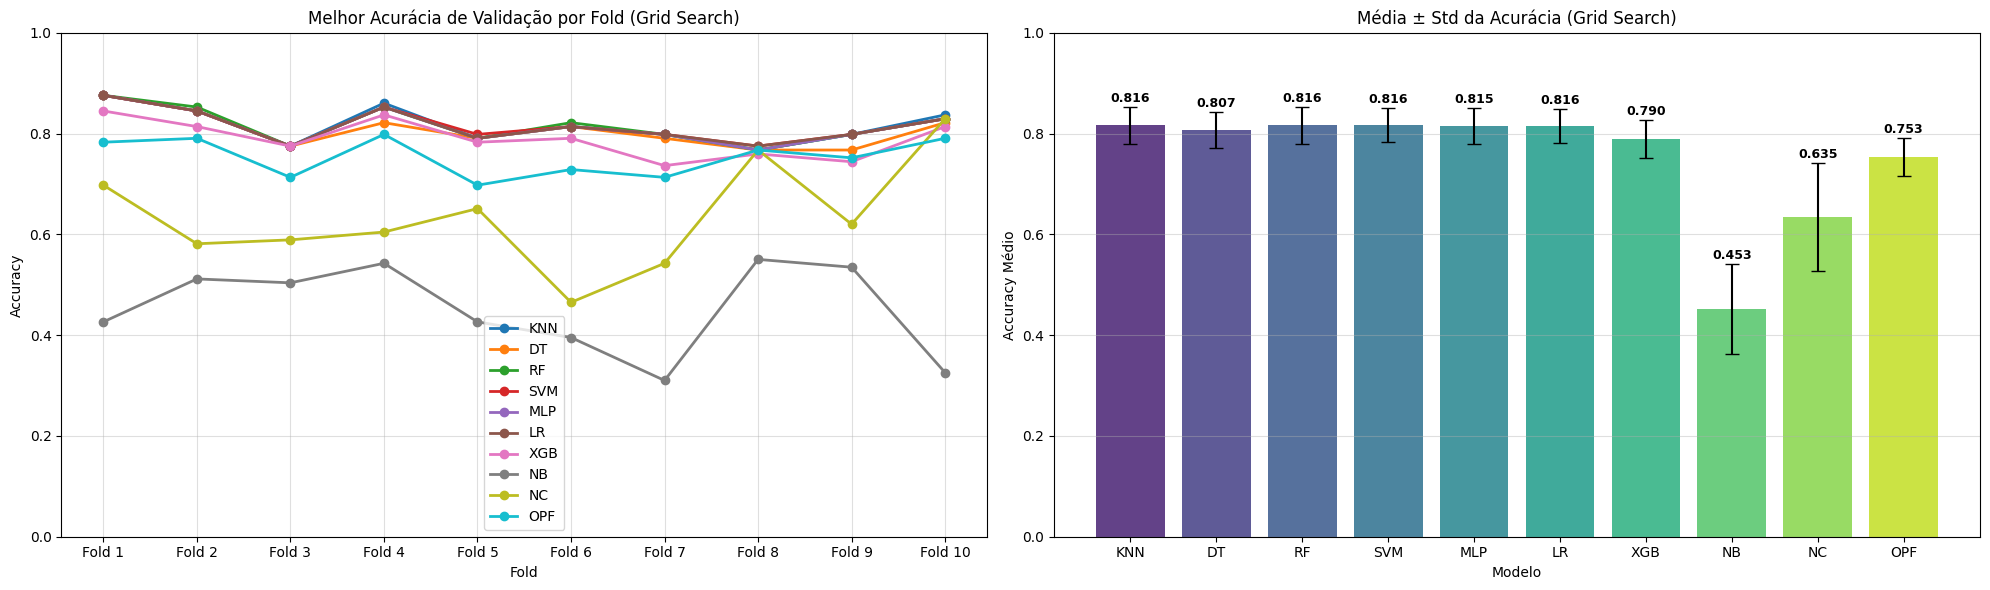

In [65]:
df_gs_acc = pd.DataFrame(gridsearch_results_acc, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_acc['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs_acc.columns:
    axes[0].plot(df_gs_acc.index, df_gs_acc[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor Acurácia de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs_acc.mean()
stds = df_gs_acc.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std da Acurácia (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Accuracy Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


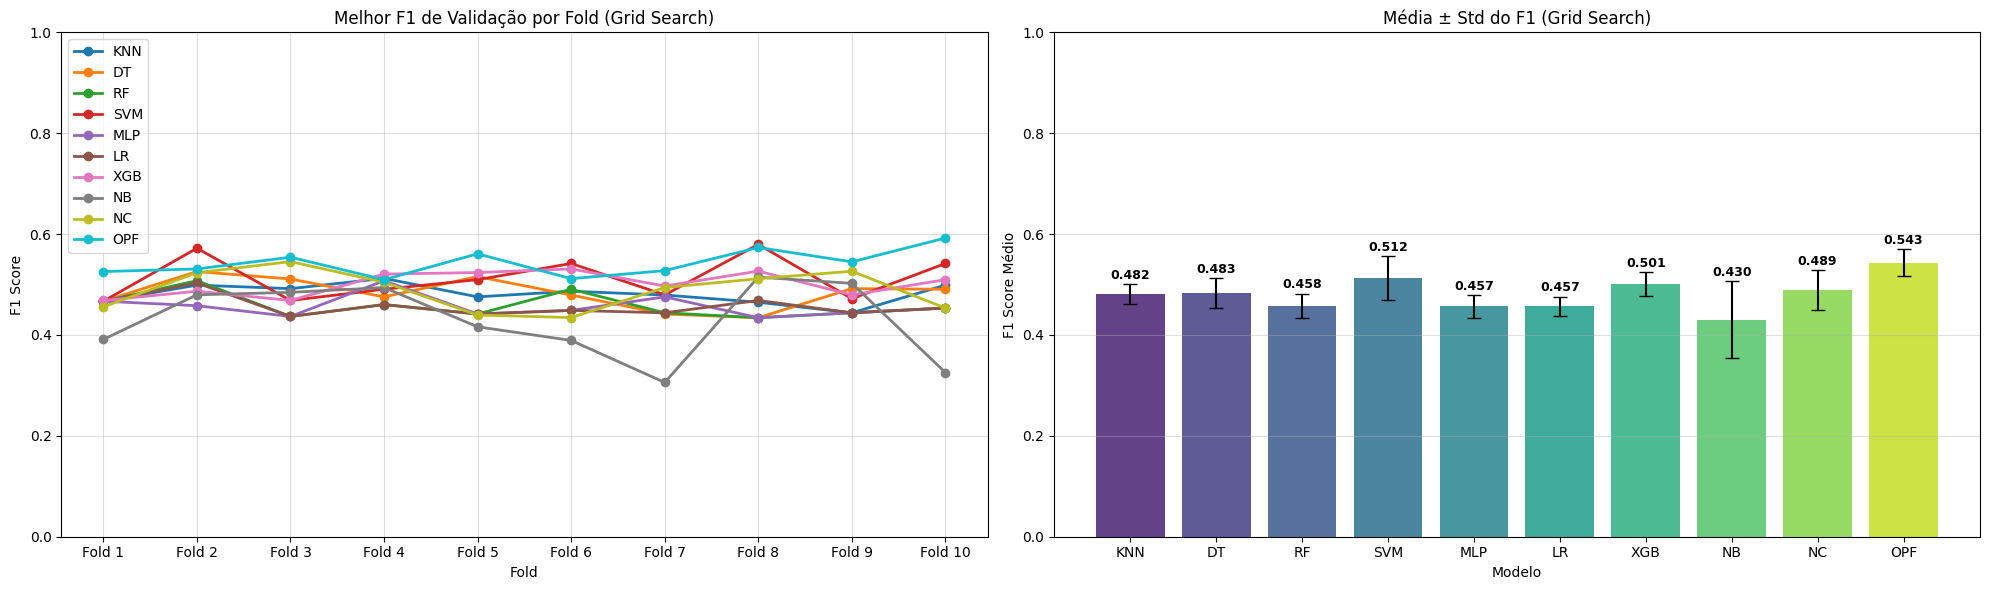

In [66]:
df_gs = pd.DataFrame(gridsearch_results_f1, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_f1['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs.columns:
    axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor F1 de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs.mean()
stds = df_gs.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std do F1 (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('F1 Score Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


In [67]:
# for metric in ['f1', 'acc']:
#     df_gs = pd.DataFrame({m: gridsearch_results[m][metric] for m in gridsearch_results},
#                           index=[f'Fold {i+1}' for i in range(5)])

#     fig, axes = plt.subplots(1, 2, figsize=(20, 6))
#     title = 'F1 Score' if metric == 'f1' else 'Acurácia'

#     for model in df_gs.columns:
#         axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
#     axes[0].set_title(f'Melhor {title} de Validação por Fold (Grid Search)')
#     axes[0].set_xlabel('Fold')
#     axes[0].set_ylabel(title)
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.4)
#     axes[0].set_ylim(0, 1)

#     means, stds = df_gs.mean(), df_gs.std()
#     bars = axes[1].bar(means.index, means.values, yerr=stds.values,
#                        capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
#     for bar, mean, std in zip(bars, means.values, stds.values):
#         axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
#                      f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
#     axes[1].set_title(f'Média ± Std da {title} (Grid Search)')
#     axes[1].set_xlabel('Modelo')
#     axes[1].set_ylabel(f'{title} Médio')
#     axes[1].set_ylim(0, 1)
#     axes[1].grid(True, alpha=0.4, axis='y')

#     plt.tight_layout()
#     plt.show()


In [68]:
# #Tabela vazia
# consenso_importancias = pd.DataFrame(index=X.columns)

# #Adiciona os valores do MDI
# #Computa final averages for MDI
# medias_finais_mdi = {}
# for modelo in resultados_mdi:
#     medias_finais_mdi[modelo] = np.mean(resultados_mdi[modelo], axis=0)

# #Tabela vazia
# consenso_importancias = pd.DataFrame(index=X.columns)

# #Adiciona os valores do MDI
# for nome_modelo, valores in medias_finais_mdi.items():
#     consenso_importancias[f'MDI_{nome_modelo}'] = valores

# tabela_de_ranks = consenso_importancias.rank()

# #Calcula a média global das posições
# consenso_importancias['Pontuação_Global'] = tabela_de_ranks.mean(axis=1)

# # Ordena da melhor (Top 1) para a pior
# consenso_ordenado = consenso_importancias.sort_values(by='Pontuação_Global', ascending=False)

# #Features ruins que devem ser deletadas
# qntd_lixo = 12 
# features_lixo = consenso_ordenado.index[-qntd_lixo:].tolist()

# print(f" AS {qntd_lixo} PIORES FEATURES")
# for i, f in enumerate(features_lixo):
#     print(f"{i+1}º pior: {f}")



In [69]:
# # 1. Pega as Top 15 posições do nosso Rank Global anterior (a cabeça da tabela: head)
# top_15_features = consenso_ordenado.index[:15].tolist()

# # 2. Transforma o 'X' gigantesco em um 'X_fortalecido' que tem SÓ essas 15.
# X_fortalecido = X[top_15_features]

# print(f"Colunas ativas agora {X_fortalecido.shape}:")
# for feat in top_15_features:
#     print(f"- {feat}")

# # 3. Atualiza para a esteira do Loop pegar apenas desta nova base
# X = X_fortalecido.values
# y = y.values


In [70]:
# # 1. Recupera as informações (Usando o Random Forest como base de inteligência)
# importancias_rf = medias_finais_mdi['RF']

# # 2. Criação e Ordenação
# df_80 = pd.DataFrame({'Importância': importancias_rf}, index=X.columns)
# df_80 = df_80.sort_values(by='Importância', ascending=False)

# # 3. Fazendo a Soma em Cascata (Soma Cumulativa)
# df_80['Soma_Acumulada'] = df_80['Importância'].cumsum()

# # 4. Separando as campeãs (<= 80%)
# features_80_percent = df_80[df_80['Soma_Acumulada'] <= 0.80]

# print(f"Você pode reter 80% de todo o seu modelo usando apenas as {len(features_80_percent)} primeiras features!\n")

# #CRIAÇÃO DO GRÁFICO
# fig, ax1 = plt.subplots(figsize=(14, 6))

# # A. Desenha as Barras (Quanto de peso CADA feature tem)
# ax1.bar(
#     df_80.index, df_80['Importância'], 
#     color='royalblue', edgecolor='black', alpha=0.8
# )
# ax1.set_ylabel('Ganho de Importância Individual', color='navy')
# ax1.set_xticks(range(len(df_80.index)))
# ax1.set_xticklabels(df_80.index, rotation=90, fontsize=9) # Nomes deitados no chão
# ax1.set_xlim(-0.5, len(df_80.index) - 0.5)

# # B. Cria um Eixo Y Secundário à direita para a linha que vai subindo
# ax2 = ax1.twinx()
# ax2.plot(
#     df_80.index, df_80['Soma_Acumulada'], 
#     color='red', marker='o', linewidth=2.5, markersize=5
# )
# ax2.set_ylabel('Soma Cumulativa (%)', color='darkred')
# ax2.set_ylim([0, 1.05]) # Vai de 0% até 105% no gráfico

# # C. Desenha as linhas guias do Corte de 80%
# ax2.axhline(y=0.80, color='green', linestyle=':', lw=3, label='Alvo: 80%')

# # D. Cortina vertical separando o "Joio do Trigo"
# index_corte = len(features_80_percent) - 1
# if index_corte >= 0:
#     ax1.axvline(x=index_corte + 0.5, color='gray', linestyle='--', lw=2)
#     ax1.text(index_corte + 0.8, ax1.get_ylim()[1]/2, '⬅ Zona dos 80% | Lixeira ➡', 
#              color='forestgreen', fontsize=12, fontweight='bold')

# plt.title('Análise de Corte das Features (Corte MDI de 80% - Random Forest)', fontsize=15)
# fig.tight_layout()
# plt.show()

# #  IMPRIME A LISTA DE OURO 
# print("=== AS FEATURES DE OURO QUE COMPÕEM 80% DO SEU PROJETO ===")
# for ft in features_80_percent.index:
#     print(f" -> {ft}")



RESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO

KNeighborsClassifier:
  Acurácia : 0.8025 ± 0.0496
  F1       : 0.7277 ± 0.0633
  Precision: 0.6666 ± 0.0735
  Recall   : 0.8025 ± 0.0496
  AUROC    : 0.4913 ± 0.0126

DecisionTreeClassifier:
  Acurácia : 0.8054 ± 0.0395
  F1       : 0.7315 ± 0.0559
  Precision: 0.6803 ± 0.0629
  Recall   : 0.8054 ± 0.0395
  AUROC    : 0.4952 ± 0.0110

RandomForestClassifier:
  Acurácia : 0.8166 ± 0.0447
  F1       : 0.7348 ± 0.0622
  Precision: 0.6688 ± 0.0726
  Recall   : 0.8166 ± 0.0447
  AUROC    : 0.5000 ± 0.0000

SVM:
  Acurácia : 0.8012 ± 0.0485
  F1       : 0.7378 ± 0.0653
  Precision: 0.7130 ± 0.0946
  Recall   : 0.8012 ± 0.0485
  AUROC    : 0.5058 ± 0.0260

MLPClassifier:
  Acurácia : 0.8166 ± 0.0447
  F1       : 0.7348 ± 0.0622
  Precision: 0.6688 ± 0.0726
  Recall   : 0.8166 ± 0.0447
  AUROC    : 0.5000 ± 0.0000

LogisticRegression:
  Acurácia : 0.8166 ± 0.0447
  F1       : 0.7348 ± 0.0622
  Precision: 0.6688 ± 0.0726
  Recall   : 0.8166 ± 0.0447


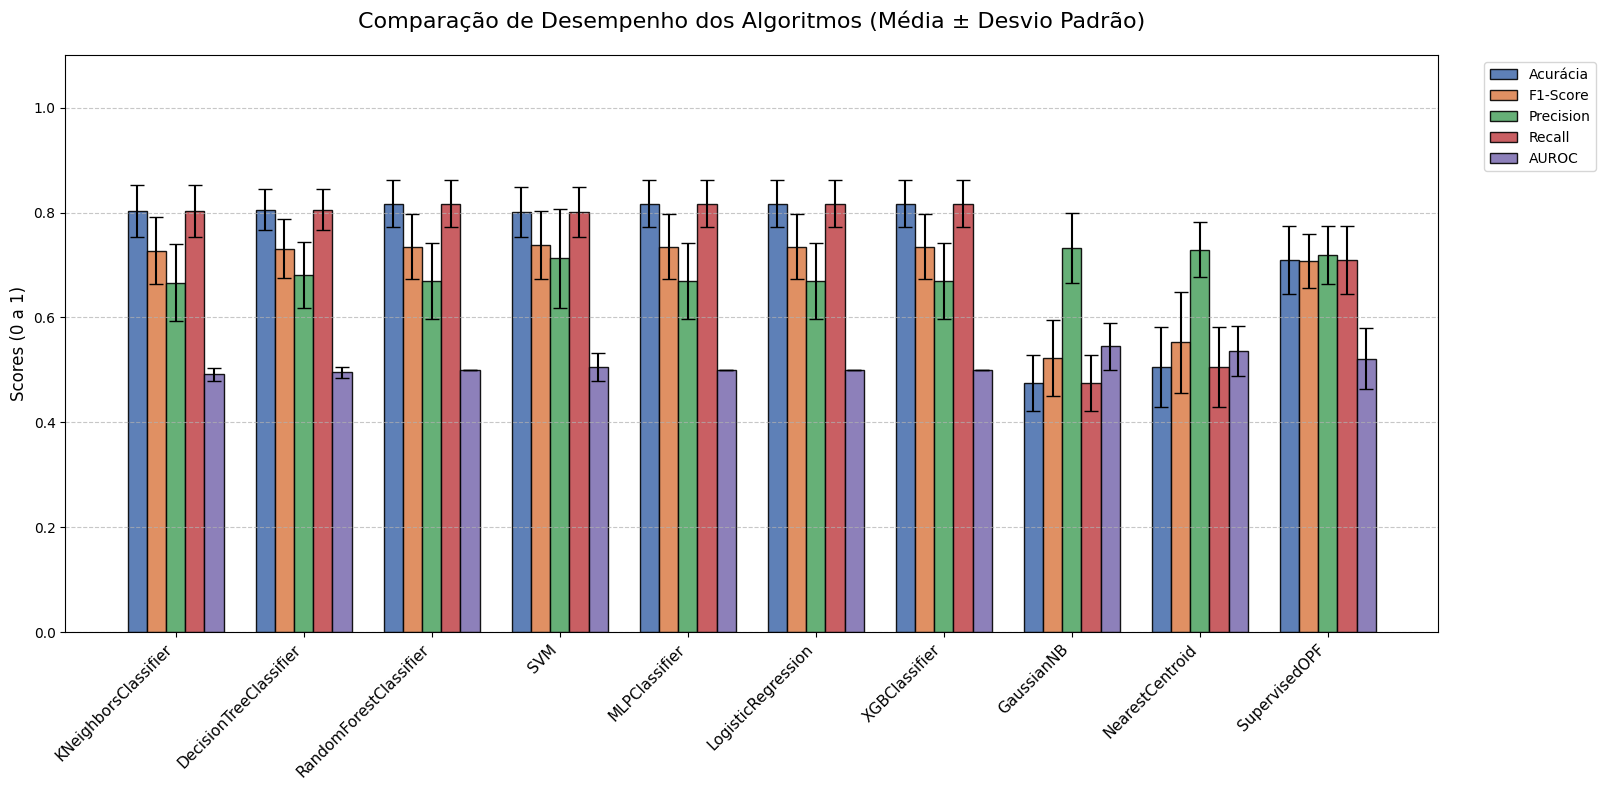

In [ ]:
print("\nRESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO")

algorithms = {
    'KNeighborsClassifier':  (acc_test_scores_KNN, f1_test_scores_KNN, precision_test_scores_KNN, recall_test_scores_KNN, auroc_test_scores_KNN),
    'DecisionTreeClassifier':(acc_test_scores_DT,  f1_test_scores_DT,  precision_test_scores_DT,  recall_test_scores_DT,  auroc_test_scores_DT),
    'RandomForestClassifier':(acc_test_scores_RF,  f1_test_scores_RF,  precision_test_scores_RF,  recall_test_scores_RF,  auroc_test_scores_RF),
    'SVM':                   (acc_test_scores_SVM, f1_test_scores_SVM, precision_test_scores_SVM, recall_test_scores_SVM, auroc_test_scores_SVM),
    'MLPClassifier':         (acc_test_scores_MLP, f1_test_scores_MLP, precision_test_scores_MLP, recall_test_scores_MLP, auroc_test_scores_MLP),
    'LogisticRegression':    (acc_test_scores_LR,  f1_test_scores_LR,  precision_test_scores_LR,  recall_test_scores_LR,  auroc_test_scores_LR),
    'XGBClassifier':         (acc_test_scores_XGB, f1_test_scores_XGB, precision_test_scores_XGB, recall_test_scores_XGB, auroc_test_scores_XGB),
    'GaussianNB':           (acc_test_scores_NB,  f1_test_scores_NB,  precision_test_scores_NB,  recall_test_scores_NB,  auroc_test_scores_NB),
    'NearestCentroid':      (acc_test_scores_NC,  f1_test_scores_NC,  precision_test_scores_NC,  recall_test_scores_NC,  auroc_test_scores_NC),
    'SupervisedOPF':        (acc_test_scores_OPF, f1_test_scores_OPF, precision_test_scores_OPF, recall_test_scores_OPF, auroc_test_scores_OPF)
}

for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    print(f"\n{name}:")
    print(f"  Acurácia : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  F1       : {np.mean(f1):.4f} ± {np.std(f1):.4f}")
    print(f"  Precision: {np.mean(precision):.4f} ± {np.std(precision):.4f}")
    print(f"  Recall   : {np.mean(recall):.4f} ± {np.std(recall):.4f}")
    print(f"  AUROC    : {np.mean(auroc):.4f} ± {np.std(auroc):.4f}")


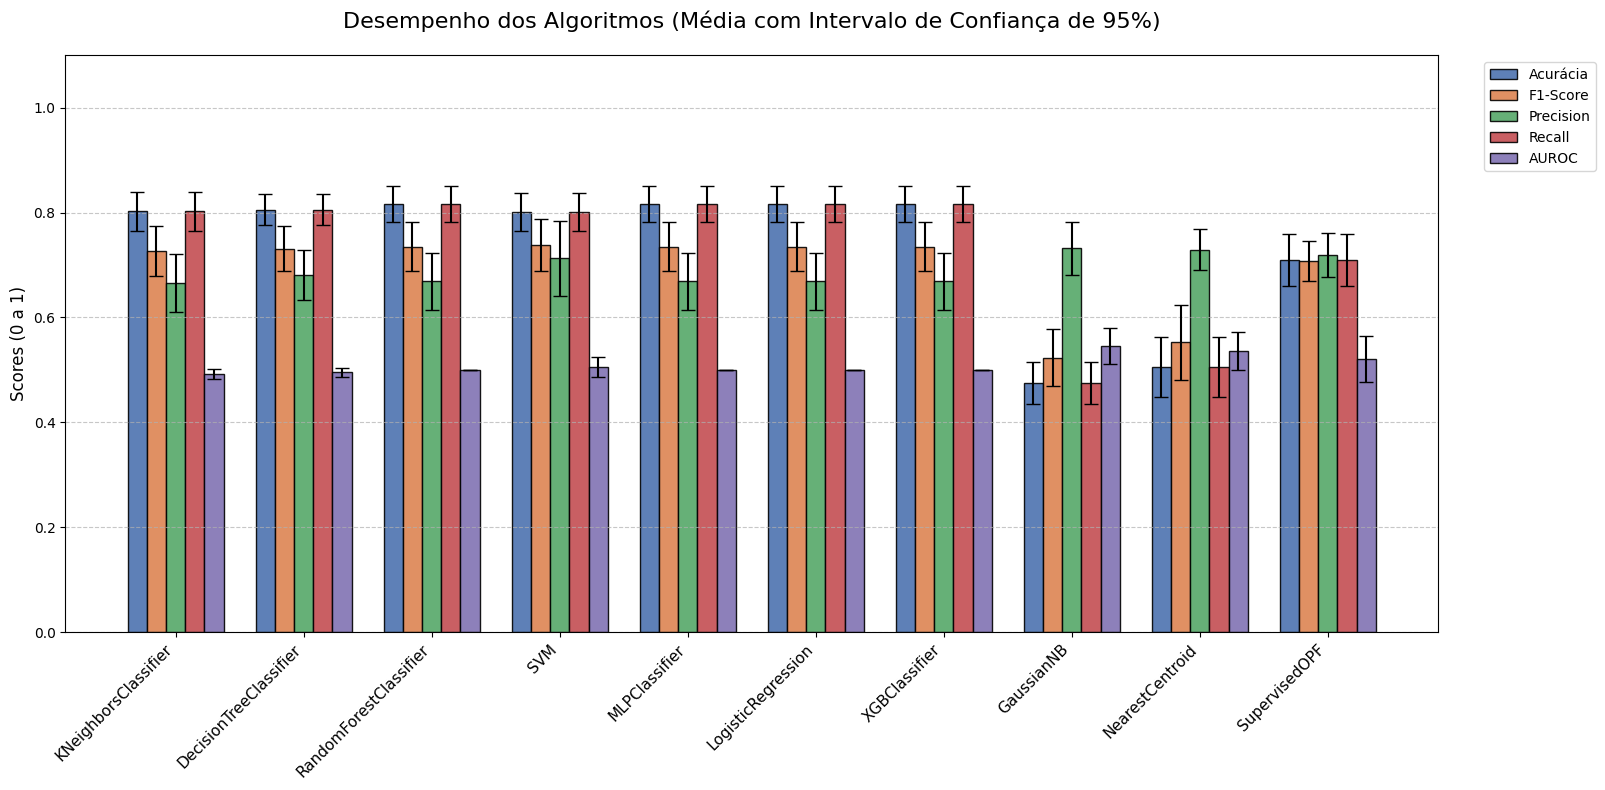

In [76]:
import scipy.stats as st

# Função matemática para calcular a margem de erro do IC de 95%
def get_confidence_interval(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    se = st.sem(data) # Erro Padrão da Média
    # h é o 'tamanho' do intervalo (para cima e para baixo)
    h = se * st.t.ppf((1 + confidence) / 2., n-1) 
    return h if not np.isnan(h) else 0.0
model_names = list(algorithms.keys())
metric_names = ['Acurácia', 'F1-Score', 'Precision', 'Recall', 'AUROC']
# Matrizes para as médias e para o Intervalo de Confiança (CI)
means = {m: [] for m in metric_names}
cis = {m: [] for m in metric_names}
for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    metrics_data = [acc, f1, precision, recall, auroc]
    
    for i, metric in enumerate(metric_names):
        means[metric].append(np.mean(metrics_data[i]))
        # Ao invés do desvio padrão, agora pegamos a margem de erro do IC
        cis[metric].append(get_confidence_interval(metrics_data[i]))
# --- Parte Visual do Gráfico ---
x = np.arange(len(model_names))
width = 0.15
fig, ax = plt.subplots(figsize=(16, 8))
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for i, metric in enumerate(metric_names):
    offset = (i - len(metric_names)/2 + 0.5) * width
    
    # O yerr agora recebe os Intervalos de Confiança
    ax.bar(x + offset, means[metric], width, yerr=cis[metric], 
           label=metric, color=cores[i], capsize=5, alpha=0.9, edgecolor='black')
ax.set_ylabel('Scores (0 a 1)', fontsize=12)
ax.set_title('Desempenho dos Algoritmos (Média com Intervalo de Confiança de 95%)', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1))
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

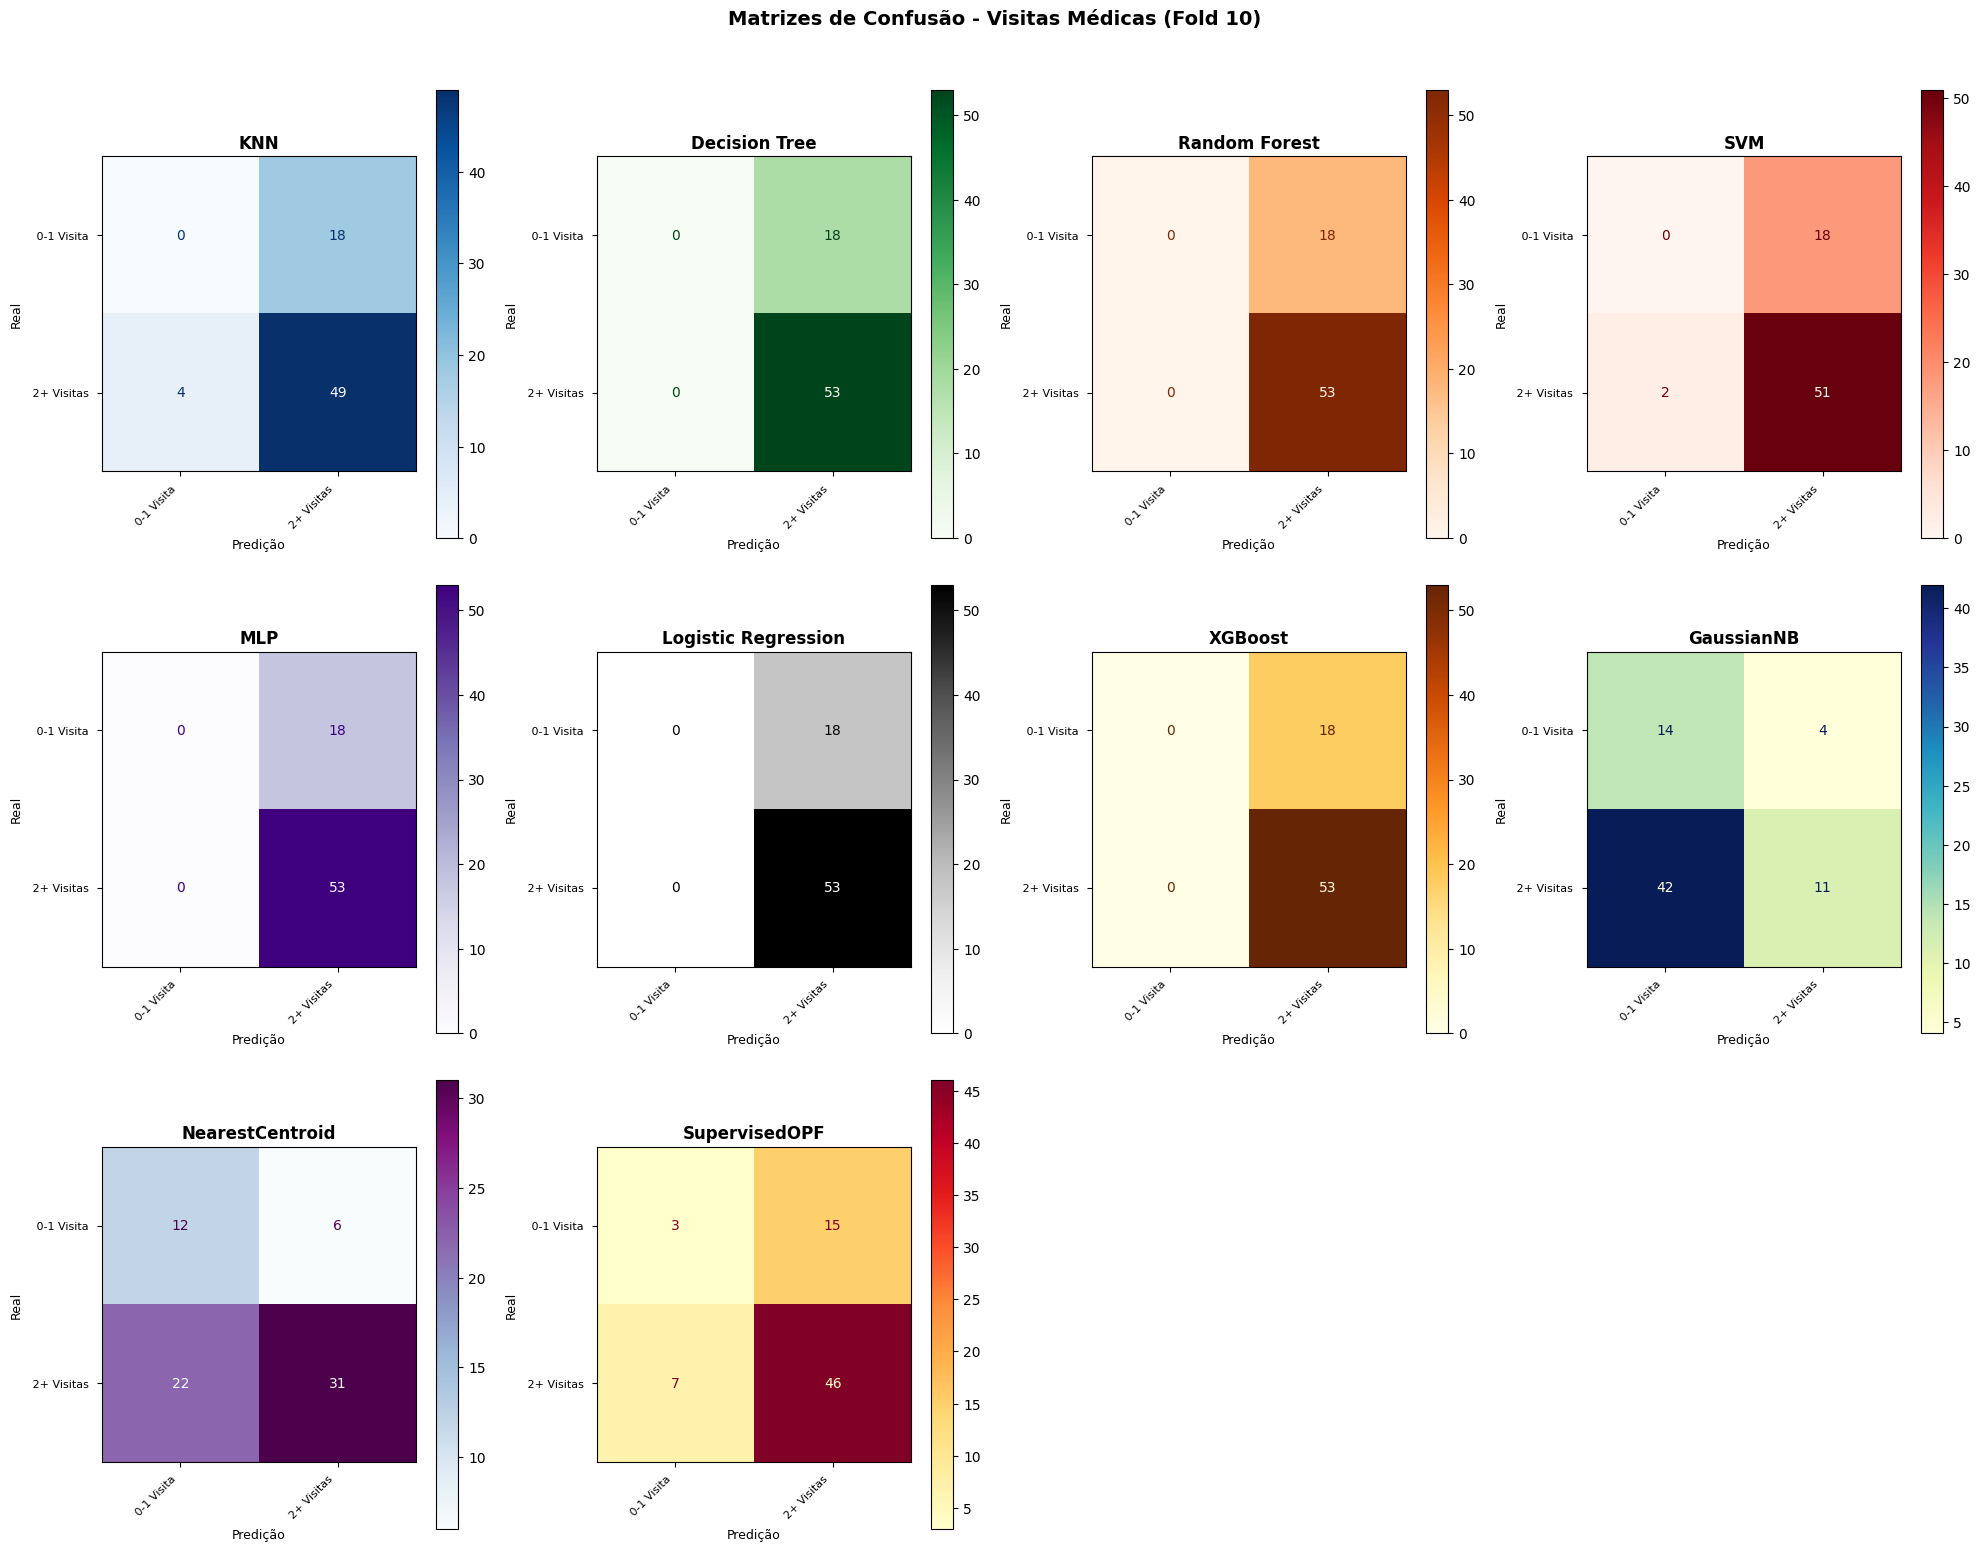

In [ ]:
plt.figure(figsize=(20, 16))  # altura maior para 3 linhas
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'MLP', 'Logistic Regression', 'XGBoost', 'GaussianNB', 'NearestCentroid', 'SupervisedOPF']
confusion_matrices = [cm_knn, cm_dt, cm_rf, cm_svm, cm_mlp, cm_lr, cm_xgb, cm_nb, cm_nc, cm_opf]
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Greys', 'YlOrBr', 'YlGnBu', 'BuPu', 'YlOrRd']

class_labels = [' 0-1 Visita ', ' 2+ Visitas ']

for j, (model, cm, color) in enumerate(zip(models, confusion_matrices, colors)):
    plt.subplot(3, 4, j+1)  # ← (3, 4) em vez de (2, 4)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=color, ax=plt.gca(), values_format='d')

    plt.title(f'{model}', fontsize=12, fontweight='bold')
    plt.xlabel('Predição', fontsize=9)
    plt.ylabel('Real', fontsize=9)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle(f'Matrizes de Confusão - Visitas Médicas (Fold {i+1})',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [ ]:
all_metrics_results = {
    'Acurácia': [
        ('KNeighborsClassifier', acc_test_scores_KNN),
        ('DecisionTreeClassifier', acc_test_scores_DT),
        ('RandomForestClassifier', acc_test_scores_RF),
        ('SVM', acc_test_scores_SVM),
        ('MLPClassifier', acc_test_scores_MLP),
        ('LogisticRegression', acc_test_scores_LR),
        ('XGBClassifier', acc_test_scores_XGB),
        ('GaussianNB', acc_test_scores_NB),
        ('NearestCentroid', acc_test_scores_NC),
        ('SupervisedOPF', acc_test_scores_OPF)
         
    ],
    'Precisão': [
        ('KNeighborsClassifier', precision_test_scores_KNN),
        ('DecisionTreeClassifier', precision_test_scores_DT),
        ('RandomForestClassifier', precision_test_scores_RF),
        ('SVM', precision_test_scores_SVM),
        ('MLPClassifier', precision_test_scores_MLP),
        ('LogisticRegression', precision_test_scores_LR),
        ('XGBClassifier', precision_test_scores_XGB),
        ('GaussianNB', precision_test_scores_NB),
        ('NearestCentroid', precision_test_scores_NC),
        ('SupervisedOPF', precision_test_scores_OPF)

    ],
    'Recall': [
        ('KNeighborsClassifier', recall_test_scores_KNN),
        ('DecisionTreeClassifier', recall_test_scores_DT),
        ('RandomForestClassifier', recall_test_scores_RF),
        ('SVM', recall_test_scores_SVM),
        ('MLPClassifier', recall_test_scores_MLP),
        ('LogisticRegression', recall_test_scores_LR),
        ('XGBClassifier', recall_test_scores_XGB),
        ('GaussianNB', recall_test_scores_NB),
        ('NearestCentroid', recall_test_scores_NC),
        ('SupervisedOPF', recall_test_scores_OPF)

    ],
    'F1-Score': [
        ('KNeighborsClassifier', f1_test_scores_KNN),
        ('DecisionTreeClassifier', f1_test_scores_DT),
        ('RandomForestClassifier', f1_test_scores_RF),
        ('SVM', f1_test_scores_SVM),
        ('MLPClassifier', f1_test_scores_MLP),
        ('LogisticRegression', f1_test_scores_LR),
        ('XGBClassifier', f1_test_scores_XGB),
        ('GaussianNB', f1_test_scores_NB),
        ('NearestCentroid', f1_test_scores_NC),
        ('SupervisedOPF', f1_test_scores_OPF)
    ],
    'AUROC': [
        ('KNeighborsClassifier', auroc_test_scores_KNN),
        ('DecisionTreeClassifier', auroc_test_scores_DT),
        ('RandomForestClassifier', auroc_test_scores_RF),
        ('SVM', auroc_test_scores_SVM),
        ('MLPClassifier', auroc_test_scores_MLP),
        ('LogisticRegression', auroc_test_scores_LR),
        ('XGBClassifier', auroc_test_scores_XGB),
        ('GaussianNB', auroc_test_scores_NB),
        ('NearestCentroid', auroc_test_scores_NC),
        ('SupervisedOPF', auroc_test_scores_OPF)
    ]
}

alpha = 0.05

for metric_name, model_scores_list in all_metrics_results.items():

    for i in range(len(model_scores_list)):
        for j in range(i + 1, len(model_scores_list)):
            model1_name, scores1 = model_scores_list[i]
            model2_name, scores2 = model_scores_list[j]

            print(f"\nComparando {model1_name} x {model2_name}:")

            if len(scores1) != len(scores2):
                print(f"\t- ERRO: Tamanhos das listas de scores são diferentes.")
                continue
            if len(scores1) < 2:
                print("\t- ERRO: Não há scores suficientes para o teste.")
                continue

            try:
                stat, p_val = wilcoxon(scores1, scores2, zero_method='zsplit', correction=False)
            except ValueError as e:
                print(f"\t- AVISO: Teste de Wilcoxon não pôde ser calculado. ({e})")
                mean1 = np.mean(scores1)
                mean2 = np.mean(scores2)
                print(f"\t- Média {model1_name}: {mean1:.4f}")
                print(f"\t- Média {model2_name}: {mean2:.4f}")
                print("\t-> Sem conclusão estatística.")
                print("----------------------------------------")
                continue

            mean1 = np.mean(scores1)
            mean2 = np.mean(scores2)

            print(f"\t- Amostras (n): {len(scores1)}")
            print(f"\t- Média {model1_name}: {mean1:.4f}")
            print(f"\t- Média {model2_name}: {mean2:.4f}")
            print(f"\t- Estatística Z: {stat:.4f}")
            print(f"\t- Valor-p (p-value): {p_val:.4f}")

            if p_val < alpha:
                print(f"\t-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha}).")
                best_model = model1_name if mean1 > mean2 else model2_name
                print(f"\t-> Melhor modelo (pela média): {best_model}")
            else:
                print(f"\t-> Resultado: Sem diferença estatisticamente significativa (p >= {alpha}).")

            print("----------------------------------------")


Comparando KNeighborsClassifier x DecisionTreeClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8124
	- Média DecisionTreeClassifier: 0.7927
	- Estatística Z: 5.0000
	- Valor-p (p-value): 0.0234
	-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05).
	-> Melhor modelo (pela média): KNeighborsClassifier
----------------------------------------

Comparando KNeighborsClassifier x RandomForestClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8124
	- Média RandomForestClassifier: 0.8166
	- Estatística Z: 18.0000
	- Valor-p (p-value): 0.5000
	-> Resultado: Sem diferença estatisticamente significativa (p >= 0.05).
----------------------------------------

Comparando KNeighborsClassifier x SVM:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8124
	- Média SVM: 0.8012
	- Estatística Z: 12.0000
	- Valor-p (p-value): 0.1328
	-> Resultado: Sem diferença estatisticamente significativa (p >= 0.05).
----------------------------------------

Comparando K